<a href="https://colab.research.google.com/github/anudaindu/Mobitel_Alarm_Fault_Prediction/blob/main/newmobi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 4G Telecom Data Preparation and Analysis Pipeline

### Step 1: Drive Mounting & File Merging

This step mounts your Google Drive, searches for all CSV and Excel files within a specified folder, and merges them into a single Pandas DataFrame. It also prints the initial row and column counts to give an overview of the raw data size.

In [22]:
from google.colab import drive
import glob
import os
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Specify the folder path in your Google Drive
# IMPORTANT: Update this path to where your telecom data files are located
folder_path = '/content/drive/MyDrive/MobitelData/mobi_data2'

# Ensure the folder exists
if not os.path.exists(folder_path):
    raise FileNotFoundError(f"The specified folder does not exist: {folder_path}")

# 3. Search for CSV and Excel files
excel_files = glob.glob(os.path.join(folder_path, "*.xlsx"))
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
all_files = excel_files + csv_files

if not all_files:
    raise ValueError(f"No CSV or Excel files found in the specified folder: {folder_path}")

print(f"Found {len(excel_files)} Excel files and {len(csv_files)} CSV files (Total: {len(all_files)} files).")

# Helper function to read either CSV or Excel seamlessly
def read_log_file(file_path):
    print(f"Reading: {os.path.basename(file_path)}")
    if file_path.endswith('.csv'):
        return pd.read_csv(file_path, low_memory=False) # low_memory=False to avoid dtype warnings
    elif file_path.endswith('.xlsx'):
        return pd.read_excel(file_path)

# 4. Load all files and concatenate them into a single DataFrame
all_dataframes = []
for file in all_files:
    try:
        df = read_log_file(file)
        all_dataframes.append(df)
    except Exception as e:
        print(f"Error reading {os.path.basename(file)}: {e}")

if not all_dataframes:
    raise ValueError("No dataframes could be loaded from the files.")

merged_df = pd.concat(all_dataframes, ignore_index=True)

# Print initial row and column counts
print(f"\nInitial merged DataFrame shape: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns.")
display(merged_df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 10 Excel files and 0 CSV files (Total: 10 files).
Reading: AlarmLogs20260803113740030_4.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Reading: AlarmLogs20260803113740030_5.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Reading: AlarmLogs20260803113740030_6.xlsx


...

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Reading: AlarmLogs20260803113740030_11.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Reading: AlarmLogs20260803113740030_2.xlsx
Reading: AlarmLogs20260803113740030_7.xlsx
Reading: AlarmLogs20260803113740030_3.xlsx

Initial merged DataFrame shape: 1000000 rows, 44 columns.


,,Severity,Occurred On (NT),Cleared On (NT),Alarm ID,MO Name,Comment,Name,Location Information,Additional Information,...,RRU Name,Received On (ST),Request ID,Subnet,Toggling Times,Trouble Ticket ID,Type,User Label,eNodeB ID,gNodeB ID
0,Root alarm,Major,2026-07-02 16:57:09,2026-07-03 11:43:11,25888,MTRAT1_G0L00_Rathmale_Junction_TXD_Ma,-,SCTP Link Fault,"Link No.=70053, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:03:31,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GL,0,-,Trunk system,-,84362,-
1,Correlative alarm,Critical,2026-07-02 17:04:25,2026-07-02 17:04:32,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:04:29,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
2,Root alarm,Critical,2026-07-02 17:04:58,2026-07-02 17:05:05,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:05:04,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
3,-,Critical,2026-07-02 17:06:53,2026-07-02 17:08:39,2606,UGW02,-,Signalling path disconnected,"Local IP address=202.129.232.38, VPN=GN_VPN, P...",-,...,-,2026-07-02 17:06:54,-,ROOT/PS Core Subnet,0,-,Communication system,-,-,-
4,-,Critical,2026-07-02 17:06:59,2026-07-02 17:07:44,2606,UGW02,-,Signalling path disconnected,"Local IP address=202.129.232.40, VPN=GN_VPN, P...",-,...,-,2026-07-02 17:06:59,-,ROOT/PS Core Subnet,0,-,Communication system,-,-,-


### Column Renaming for Consistency

Based on the loaded data preview, the eNodeB ID column is named `'eNodeB ID'` and the alarm name column is named `'Name'`. For consistency with the rest of the script, we will rename these columns to `enodeb_id` and `name` respectively.

In [28]:
# Rename columns for consistency with the rest of the script
# Check if 'eNodeB ID' exists before renaming
if 'eNodeB ID' in merged_df.columns:
    merged_df.rename(columns={'eNodeB ID': 'enodeb_id'}, inplace=True)
    print("Renamed 'eNodeB ID' to 'enodeb_id'.")
else:
    print("Column 'eNodeB ID' not found for renaming to 'enodeb_id'. Please check the exact column name in your source files.")

# Check if 'Name' exists before renaming
if 'Name' in merged_df.columns:
    merged_df.rename(columns={'Name': 'name'}, inplace=True)
    print("Renamed 'Name' to 'name'.")
else:
    print("Column 'Name' not found for renaming to 'name'. Please check the exact column name in your source files.")

print("\nDataFrame columns after renaming:")
display(merged_df.columns)

Column 'eNodeB ID' not found for renaming to 'enodeb_id'. Please check the exact column name in your source files.
Column 'Name' not found for renaming to 'name'. Please check the exact column name in your source files.

DataFrame columns after renaming:


Index([' ', 'Severity', 'Occurred On (NT)', 'Cleared On (NT)', 'Alarm ID',
       'MO Name', 'Comment', 'name', 'Location Information',
       'Additional Information', 'Alarm Duration', 'Alarm Source',
       'Acknowledged By', 'Acknowledged On (ST)', 'Acknowledgement Status',
       'Associated Alarm Group ID', 'Auto Clear', 'BBU Name',
       'Clearance Status', 'Clearance Type', 'Cleared By',
       'Common Alarm Identifier', 'Dev Root CSN',
       'Equipment Alarm Serial Number', 'External Resource ID', 'Link Name',
       'Link Type', 'Log Serial Number', 'Maintenance Region',
       'Maintenance Status', 'NE Address', 'NE Type', 'Object Type',
       'Operation Impact Flag', 'RRU Name', 'Received On (ST)', 'Request ID',
       'Subnet', 'Toggling Times', 'Trouble Ticket ID', 'Type', 'User Label',
       'enodeb_id', 'gNodeB ID'],
      dtype='object')

### Column Renaming for Consistency

Based on the loaded data preview, the eNodeB ID column is named `'eNodeB ID'` and the alarm name column is named `'Name'`. For consistency with the rest of the script, we will rename these columns to `enodeb_id` and `name` respectively.

In [27]:
# Rename columns for consistency with the rest of the script
# Check if 'eNodeB ID' exists before renaming
if 'eNodeB ID' in merged_df.columns:
    merged_df.rename(columns={'eNodeB ID': 'enodeb_id'}, inplace=True)
    print("Renamed 'eNodeB ID' to 'enodeb_id'.")
else:
    print("Column 'eNodeB ID' not found for renaming to 'enodeb_id'. Please check the exact column name in your source files.")

# Check if 'Name' exists before renaming
if 'Name' in merged_df.columns:
    merged_df.rename(columns={'Name': 'name'}, inplace=True)
    print("Renamed 'Name' to 'name'.")
else:
    print("Column 'Name' not found for renaming to 'name'. Please check the exact column name in your source files.")

print("\nDataFrame columns after renaming:")
display(merged_df.columns)

Renamed 'eNodeB ID' to 'enodeb_id'.
Renamed 'Name' to 'name'.

DataFrame columns after renaming:


Index([' ', 'Severity', 'Occurred On (NT)', 'Cleared On (NT)', 'Alarm ID',
       'MO Name', 'Comment', 'name', 'Location Information',
       'Additional Information', 'Alarm Duration', 'Alarm Source',
       'Acknowledged By', 'Acknowledged On (ST)', 'Acknowledgement Status',
       'Associated Alarm Group ID', 'Auto Clear', 'BBU Name',
       'Clearance Status', 'Clearance Type', 'Cleared By',
       'Common Alarm Identifier', 'Dev Root CSN',
       'Equipment Alarm Serial Number', 'External Resource ID', 'Link Name',
       'Link Type', 'Log Serial Number', 'Maintenance Region',
       'Maintenance Status', 'NE Address', 'NE Type', 'Object Type',
       'Operation Impact Flag', 'RRU Name', 'Received On (ST)', 'Request ID',
       'Subnet', 'Toggling Times', 'Trouble Ticket ID', 'Type', 'User Label',
       'enodeb_id', 'gNodeB ID'],
      dtype='object')

### Step 2: 4G Filtering (Data Reduction Step 1)

This step filters the merged DataFrame to keep only records associated with 4G towers. It assumes that 4G towers are identified by a non-null and non-empty value in the `enodeb_id` column. Rows with missing or empty `enodeb_id` values are dropped.

In [33]:
# Make a copy to avoid modifying the original merged_df directly in place in case it's needed later
df_4g = merged_df.copy()

# The 'enodeb_id' column is now guaranteed to exist due to the previous renaming step.
# Convert enodeb_id to string to handle potential mixed types and ensure .str methods work
df_4g['enodeb_id'] = df_4g['enodeb_id'].astype(str)

# Keep ONLY rows where 'enodeb_id' is not null/empty or '-' (as requested)
initial_rows = df_4g.shape[0]
df_4g = df_4g[df_4g['enodeb_id'].str.strip() != 'nan'] # Remove 'nan' strings if any
df_4g = df_4g[df_4g['enodeb_id'].str.strip() != ''] # Remove empty strings
df_4g = df_4g[df_4g['enodeb_id'].str.strip() != '-'] # Remove '-' strings as requested by the user
df_4g = df_4g[df_4g['enodeb_id'].notna()] # Double-check for actual NaN values

print(f"\nRemoved {initial_rows - df_4g.shape[0]} rows due to null/empty or '-' 'enodeb_id'.")

# Print dataset shape after 4G filtering
print(f"DataFrame shape after 4G filtering: {df_4g.shape[0]} rows, {df_4g.shape[1]} columns.")
display(df_4g.head())


Removed 425701 rows due to null/empty or '-' 'enodeb_id'.
DataFrame shape after 4G filtering: 574299 rows, 44 columns.


,,Severity,Occurred On (NT),Cleared On (NT),Alarm ID,MO Name,Comment,name,Location Information,Additional Information,...,RRU Name,Received On (ST),Request ID,Subnet,Toggling Times,Trouble Ticket ID,Type,User Label,enodeb_id,gNodeB ID
0,Root alarm,Major,2026-07-02 16:57:09,2026-07-03 11:43:11,25888,MTRAT1_G0L00_Rathmale_Junction_TXD_Ma,-,SCTP Link Fault,"Link No.=70053, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:03:31,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GL,0,-,Trunk system,-,84362,-
1,Correlative alarm,Critical,2026-07-02 17:04:25,2026-07-02 17:04:32,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:04:29,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
2,Root alarm,Critical,2026-07-02 17:04:58,2026-07-02 17:05:05,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:05:04,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
7,Root alarm,Critical,2026-07-02 17:07:40,2026-07-02 17:08:53,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:07:43,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
8,Root alarm,Critical,2026-07-02 17:07:37,2026-07-02 17:08:56,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:08:41,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-


### Step 3: Tower-Level Filtering on 'Cell Unavailable' (Data Reduction Step 2)

This crucial step identifies `enodeb_id` towers that have experienced at least one 'cell unavailable' alarm. It then filters the entire dataset to retain *all* alarm records, including non-'cell unavailable' alarms, but *only* for these identified problematic towers. Towers that never reported a 'cell unavailable' event are completely removed from the dataset.

In [37]:
# Make a copy to preserve df_4g if needed
df_filtered_towers = df_4g.copy()

# The 'enodeb_id' and 'name' columns are now guaranteed to exist from previous steps.
# 1. Identify towers with AT LEAST ONE 'cell unavailable' alarm
# Ensure 'name' column is string type for case-insensitive search
df_filtered_towers['name'] = df_filtered_towers['name'].astype(str)

outage_towers = df_filtered_towers[
    df_filtered_towers['name'].str.contains('cell unavailable', case=False, na=False)
]['enodeb_id'].unique()

# 2. Filter the DataFrame to retain ALL alarms ONLY for these identified towers
initial_rows = df_filtered_towers.shape[0]
df_final = df_filtered_towers[df_filtered_towers['enodeb_id'].isin(outage_towers)].copy()

print(f"\nIdentified {len(outage_towers)} unique eNodeB towers that experienced 'cell unavailable' events.")
print(f"Removed {initial_rows - df_final.shape[0]} rows belonging to towers without 'cell unavailable' events.")

# Print the count of unique target 4G towers remaining and total dataset shape
remaining_towers = df_final['enodeb_id'].nunique()
print(f"Count of unique target 4G towers remaining: {remaining_towers}")

print(f"Total dataset shape after tower-level filtering: {df_final.shape[0]} rows, {df_final.shape[1]} columns.")
display(df_final.head())


Identified 399 unique eNodeB towers that experienced 'cell unavailable' events.
Removed 413742 rows belonging to towers without 'cell unavailable' events.
Count of unique target 4G towers remaining: 399
Total dataset shape after tower-level filtering: 160557 rows, 44 columns.


,,Severity,Occurred On (NT),Cleared On (NT),Alarm ID,MO Name,Comment,name,Location Information,Additional Information,...,RRU Name,Received On (ST),Request ID,Subnet,Toggling Times,Trouble Ticket ID,Type,User Label,enodeb_id,gNodeB ID
0,Root alarm,Major,2026-07-02 16:57:09,2026-07-03 11:43:11,25888,MTRAT1_G0L00_Rathmale_Junction_TXD_Ma,-,SCTP Link Fault,"Link No.=70053, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:03:31,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GL,0,-,Trunk system,-,84362,-
1,Correlative alarm,Critical,2026-07-02 17:04:25,2026-07-02 17:04:32,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:04:29,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
2,Root alarm,Critical,2026-07-02 17:04:58,2026-07-02 17:05:05,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:05:04,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
7,Root alarm,Critical,2026-07-02 17:07:40,2026-07-02 17:08:53,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:07:43,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-
8,Root alarm,Critical,2026-07-02 17:07:37,2026-07-02 17:08:56,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",-,Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-02 17:08:41,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GUL,0,-,Signaling system,-,82116,-


### Date and Time Conversion

For time-series analysis and visualization, it's essential to convert the 'Occurred On (NT)' and 'Cleared On (NT)' columns to datetime objects. This enables proper chronological ordering and time-based calculations.

In [40]:
# Convert 'Occurred On (NT)' and 'Cleared On (NT)' to datetime objects
# Using errors='coerce' will turn unparseable dates into NaT (Not a Time)
df_final['Occurred On (NT)'] = pd.to_datetime(df_final['Occurred On (NT)'], errors='coerce')
df_final['Cleared On (NT)'] = pd.to_datetime(df_final['Cleared On (NT)'], errors='coerce')

# Drop rows where 'Occurred On (NT)' couldn't be parsed, as it's critical for time-series analysis
df_final.dropna(subset=['Occurred On (NT)'], inplace=True)

print("Date columns converted to datetime format.")
print(df_final[['Occurred On (NT)', 'Cleared On (NT)']].info())

Date columns converted to datetime format.
<class 'pandas.core.frame.DataFrame'>
Index: 160557 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Occurred On (NT)  160557 non-null  datetime64[ns]
 1   Cleared On (NT)   160557 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 3.7 MB
None


### Column Selection for Focused Analysis

To streamline the DataFrame and focus only on the columns essential for alarm analysis and time-series visualization, we will now select a subset of columns from `df_final`. This reduces memory usage and simplifies subsequent operations.

In [45]:
# Define the list of essential columns
essential_columns = [
    'Severity',
    'Occurred On (NT)',
    'Cleared On (NT)',
    'Alarm ID',
    'MO Name',
    'name', # Use the renamed column 'name'
    'Location Information',
    'Additional Information',
    'enodeb_id' # Use the renamed column 'enodeb_id'
]

# Filter df_final to keep only the essential columns
df_final = df_final[essential_columns].copy()

print(f"DataFrame now contains {df_final.shape[1]} columns.")
print("Remaining columns:")
display(df_final.columns)
display(df_final.head())

DataFrame now contains 9 columns.
Remaining columns:


Index(['Severity', 'Occurred On (NT)', 'Cleared On (NT)', 'Alarm ID',
       'MO Name', 'name', 'Location Information', 'Additional Information',
       'enodeb_id'],
      dtype='object')

,Severity,Occurred On (NT),Cleared On (NT),Alarm ID,MO Name,name,Location Information,Additional Information,enodeb_id
0,Major,2026-07-02 16:57:09,2026-07-03 11:43:11,25888,MTRAT1_G0L00_Rathmale_Junction_TXD_Ma,SCTP Link Fault,"Link No.=70053, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",84362
1,Critical,2026-07-02 17:04:25,2026-07-02 17:04:32,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",82116
2,Critical,2026-07-02 17:04:58,2026-07-02 17:05:05,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",82116
7,Critical,2026-07-02 17:07:40,2026-07-02 17:08:53,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",82116
8,Critical,2026-07-02 17:07:37,2026-07-02 17:08:56,29240,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...",Cell Unavailable,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",82116


### Time Phase Visualization of Alarms Leading to Cell Unavailability (Top 15 Towers)

This section visualizes the sequence of alarms for each of the identified top 15 eNodeB towers. For each tower, a timeline plot will show the 'Occurred On (NT)' time of both 'other alarms' and 'cell unavailable' alarms, allowing us to observe patterns where other alarms might precede or co-occur with cell unavailability.

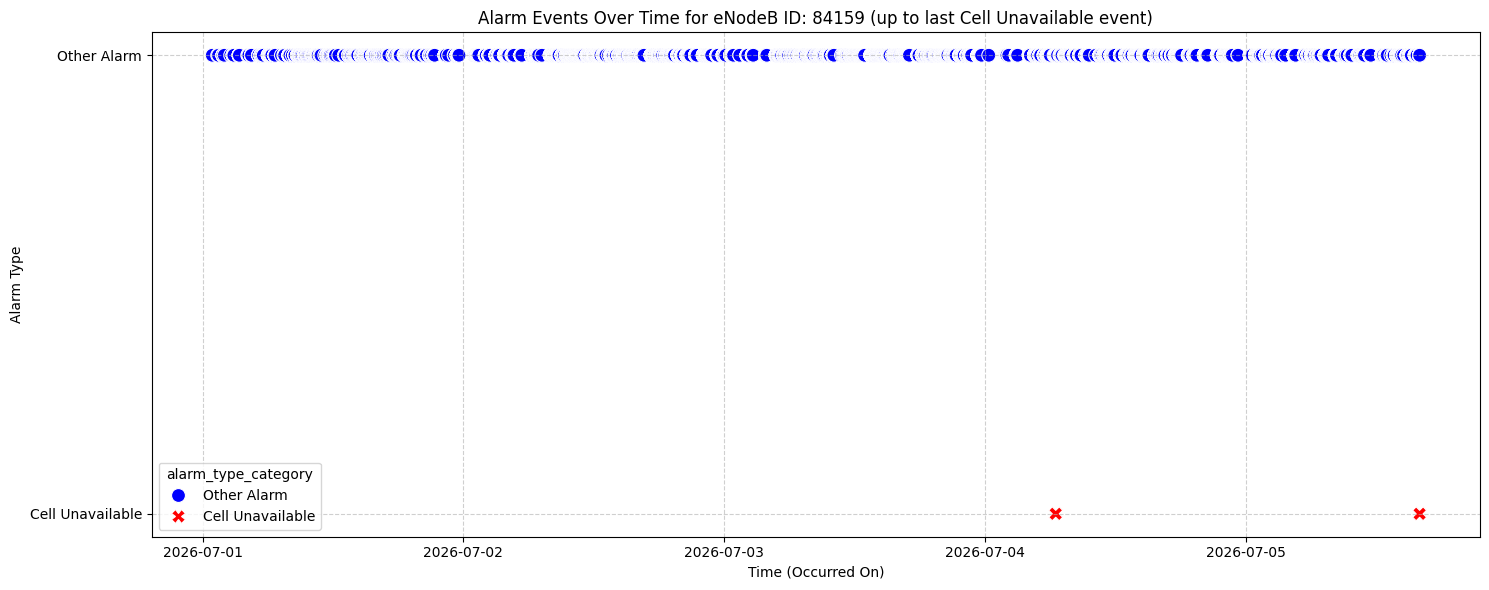

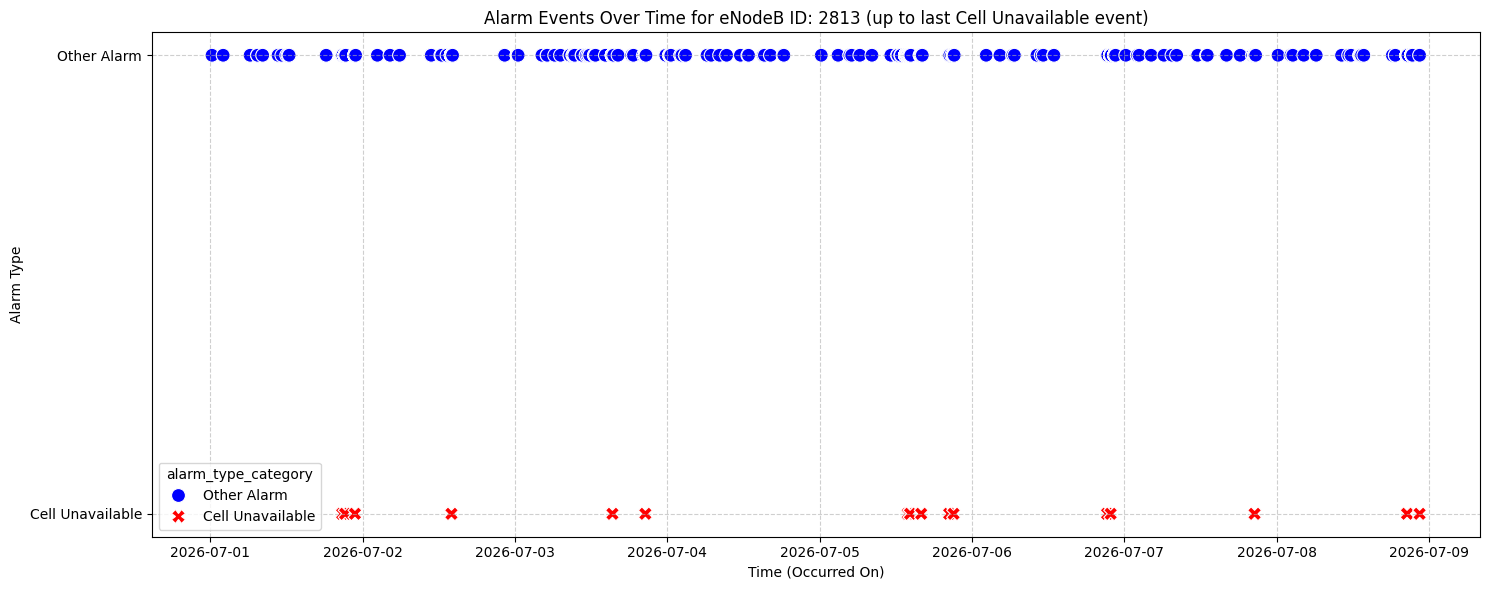

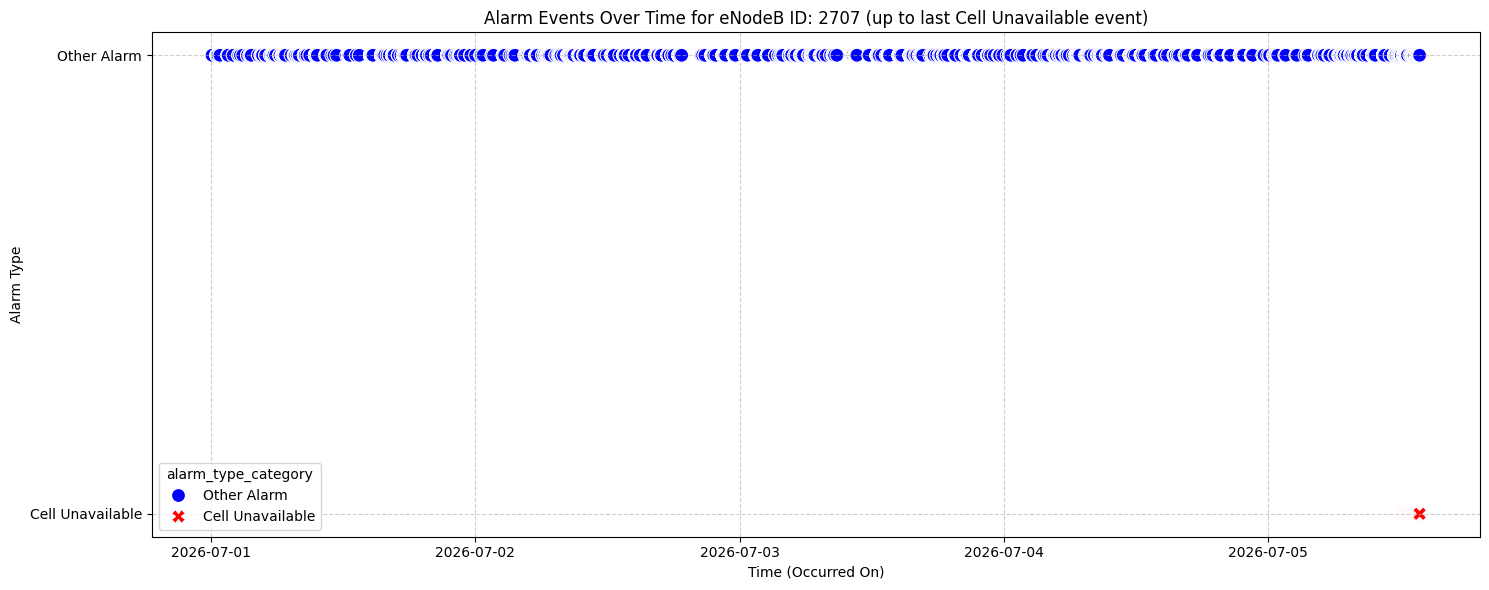

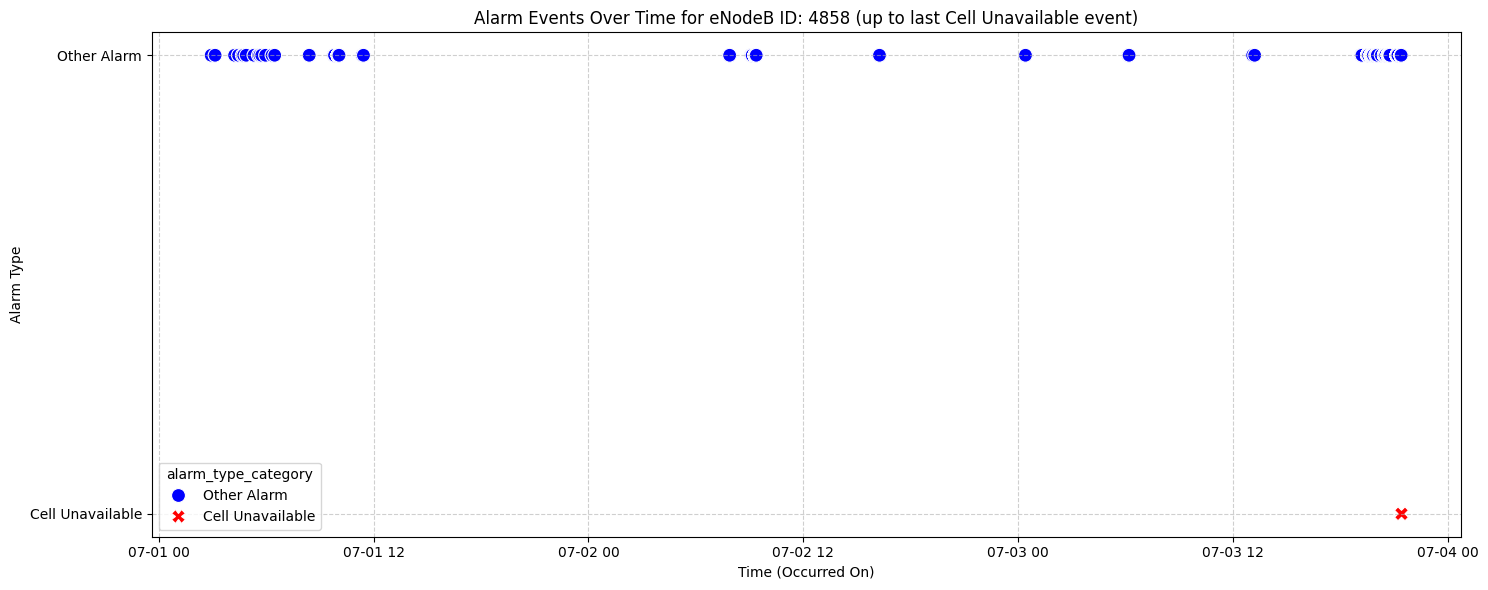

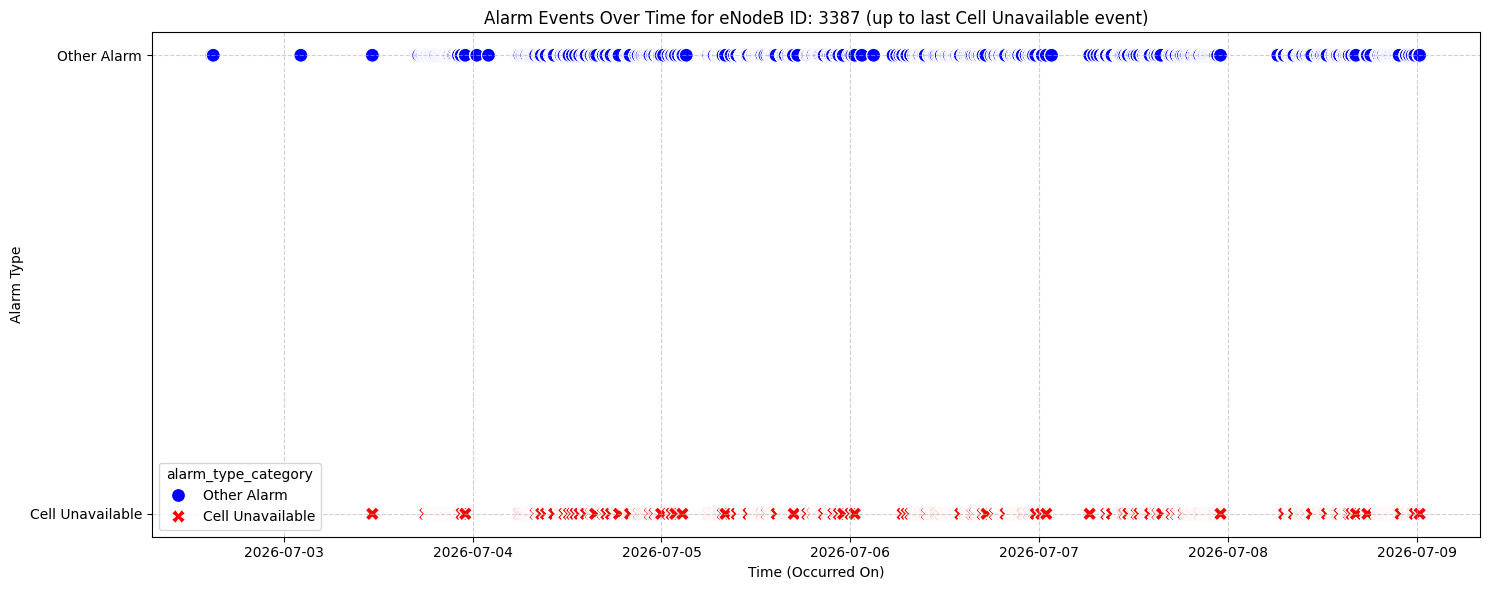

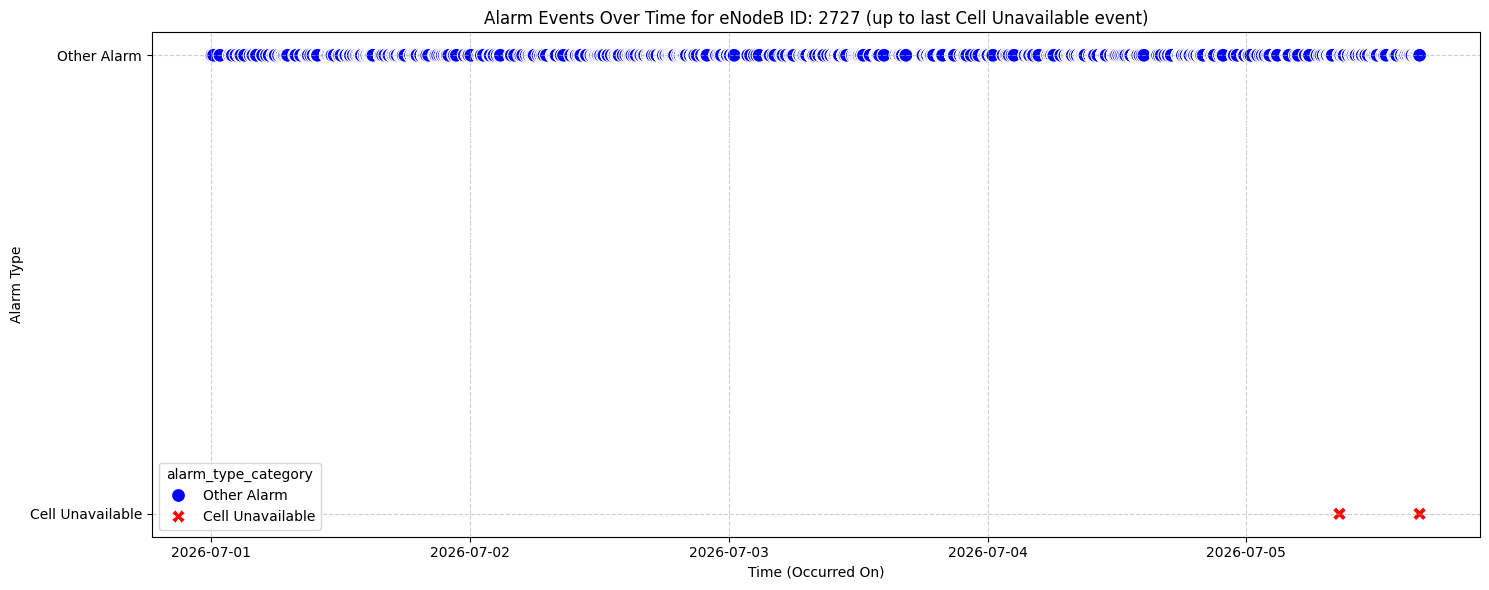

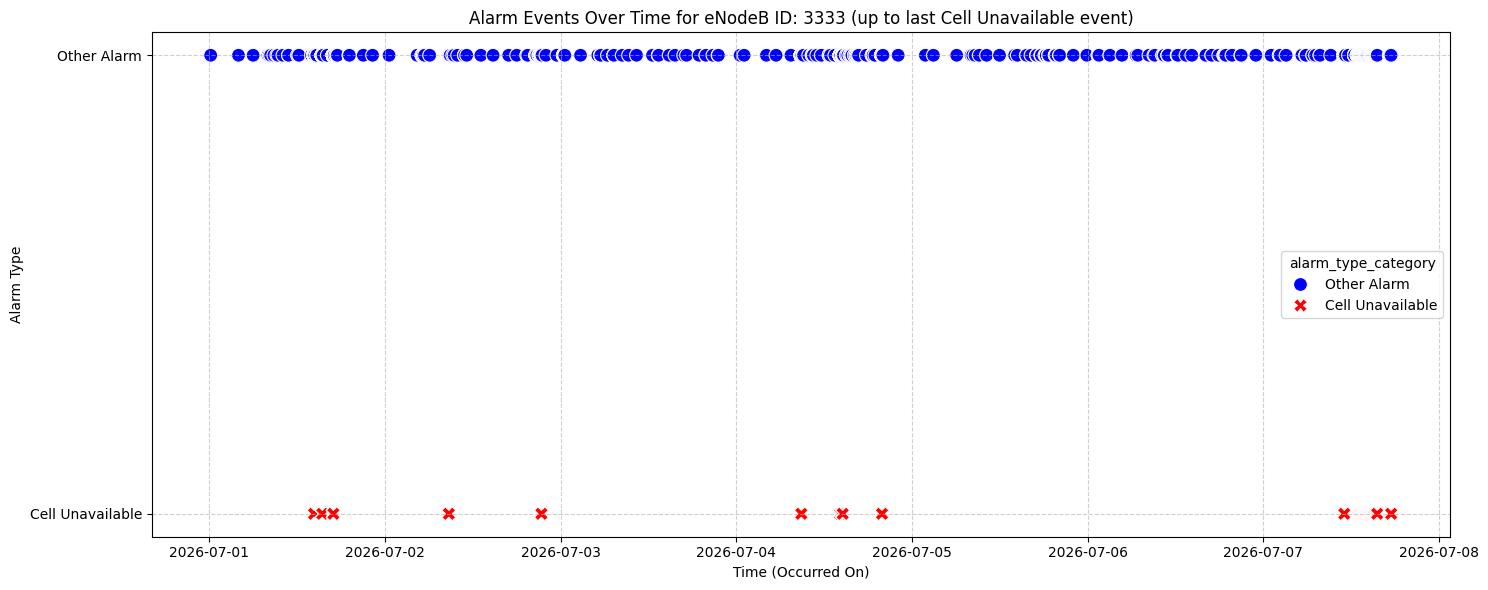

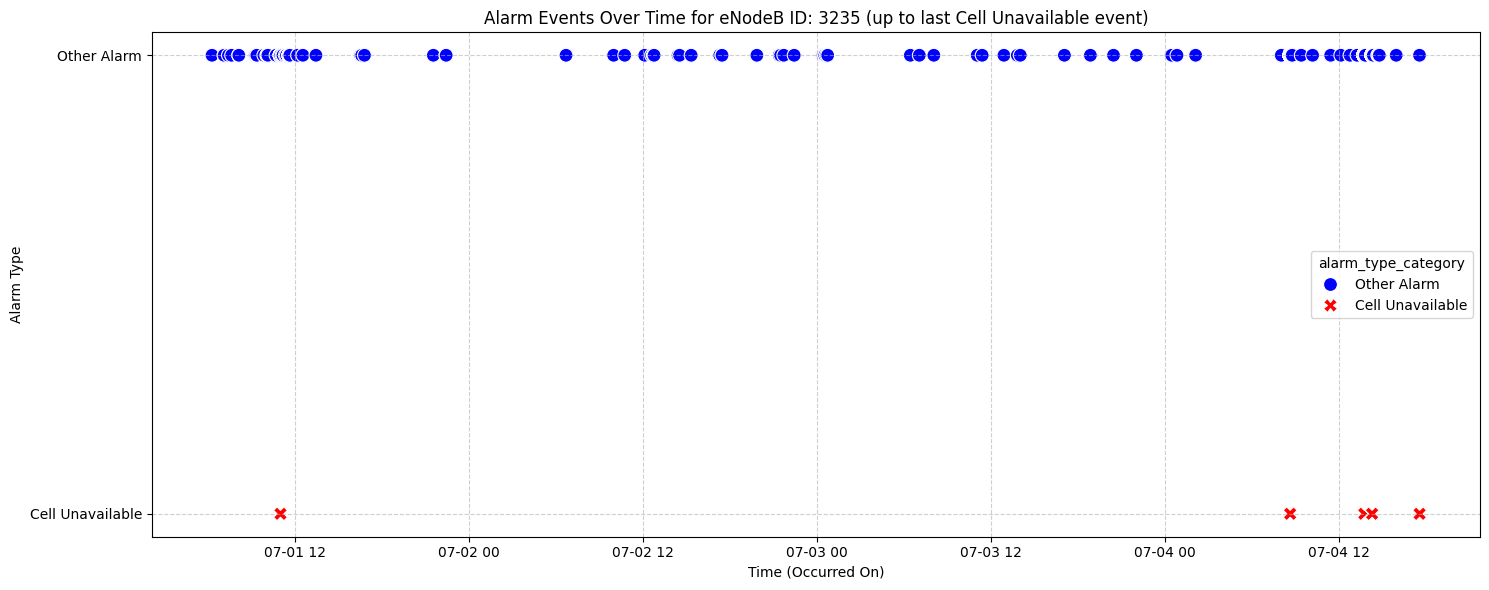

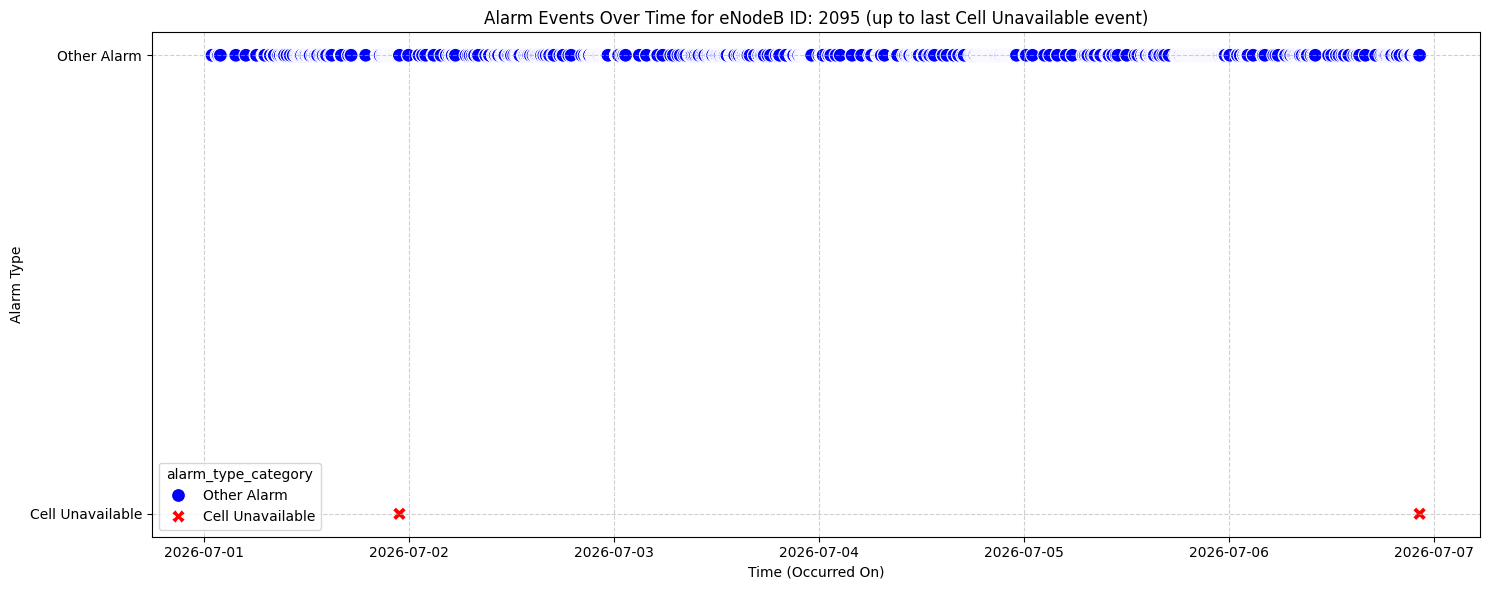

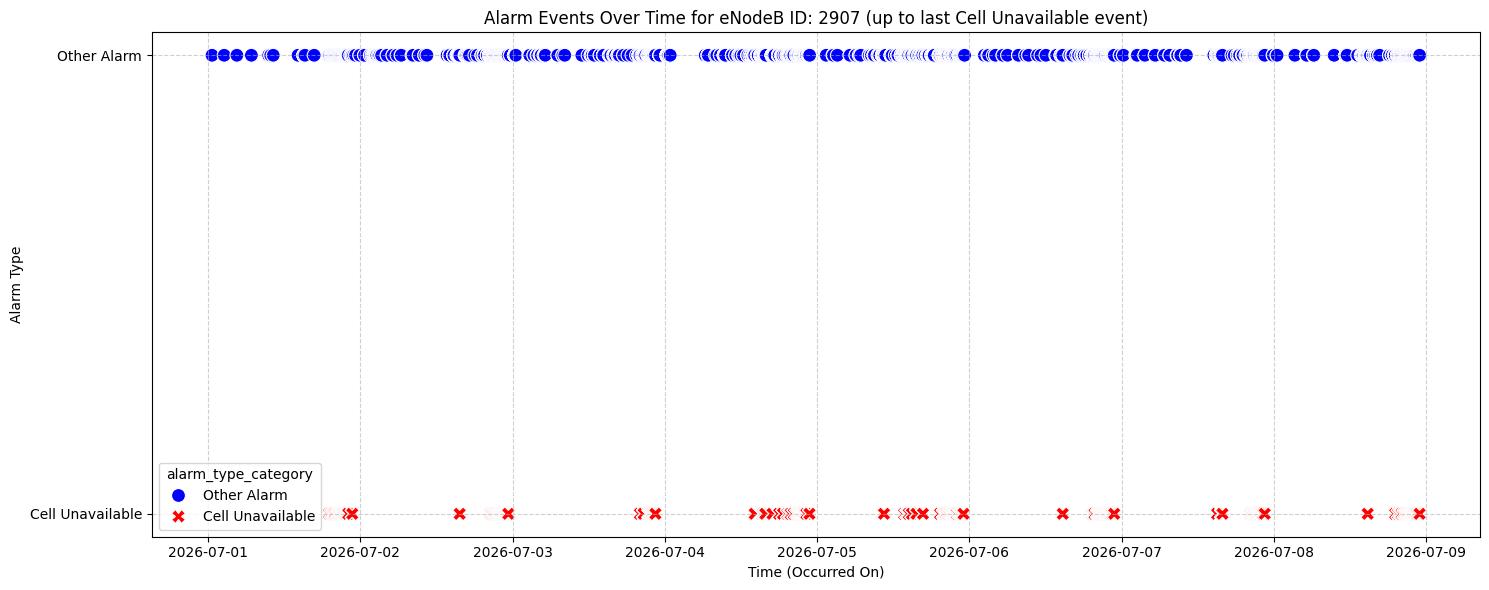

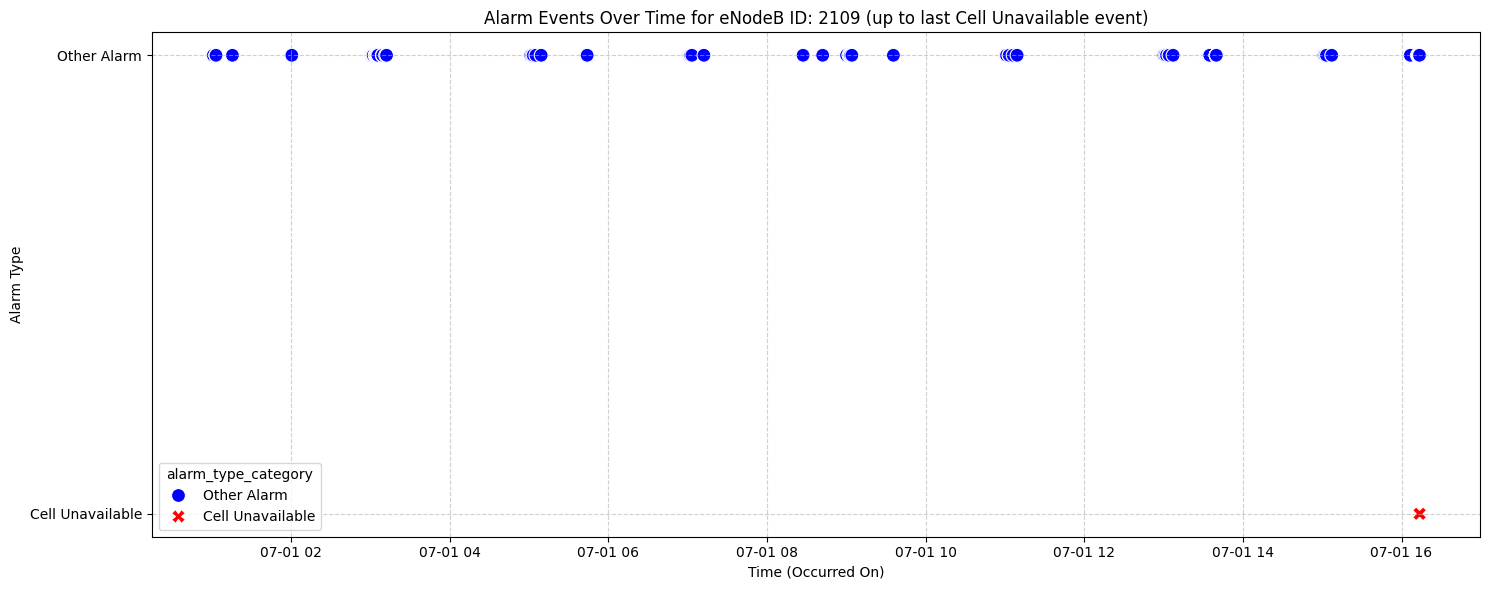

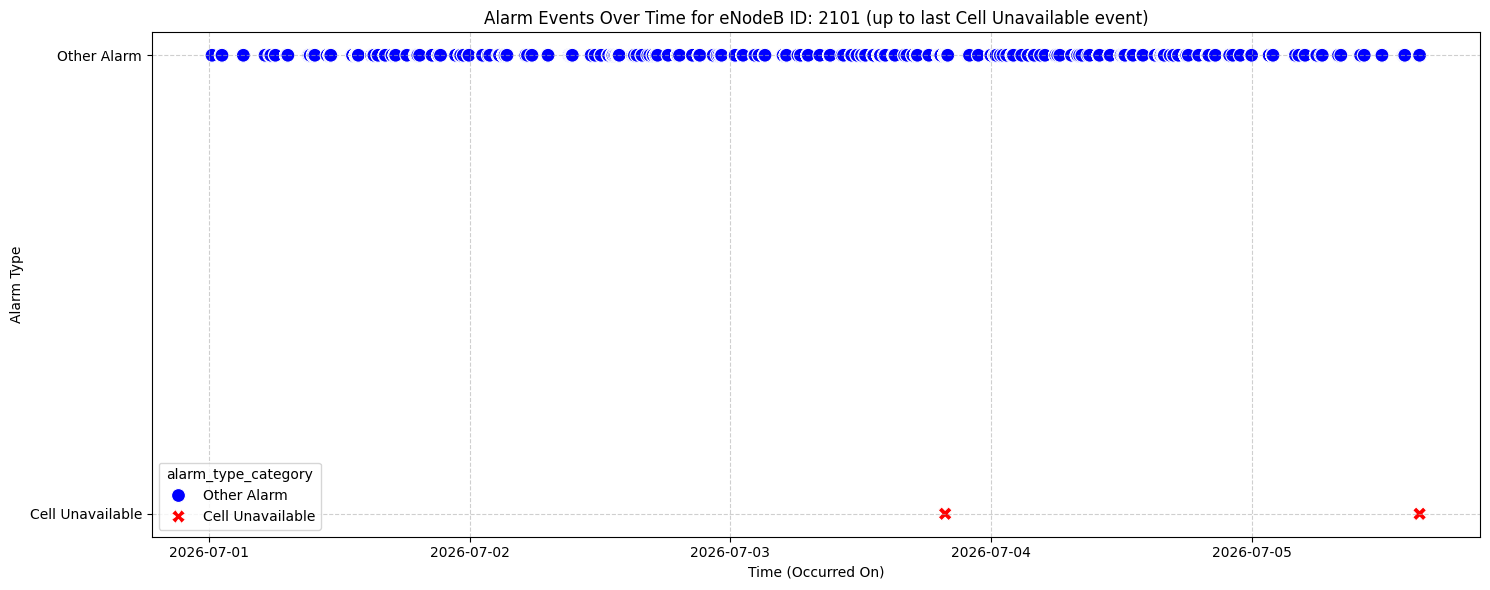

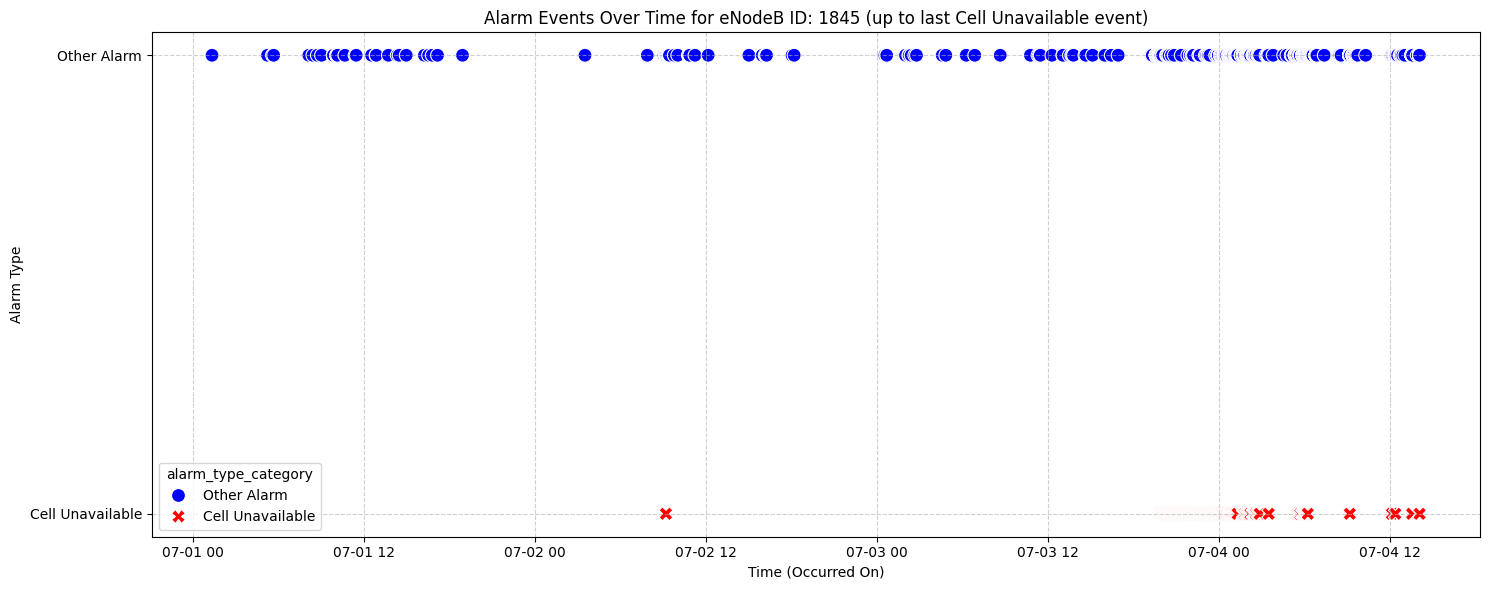

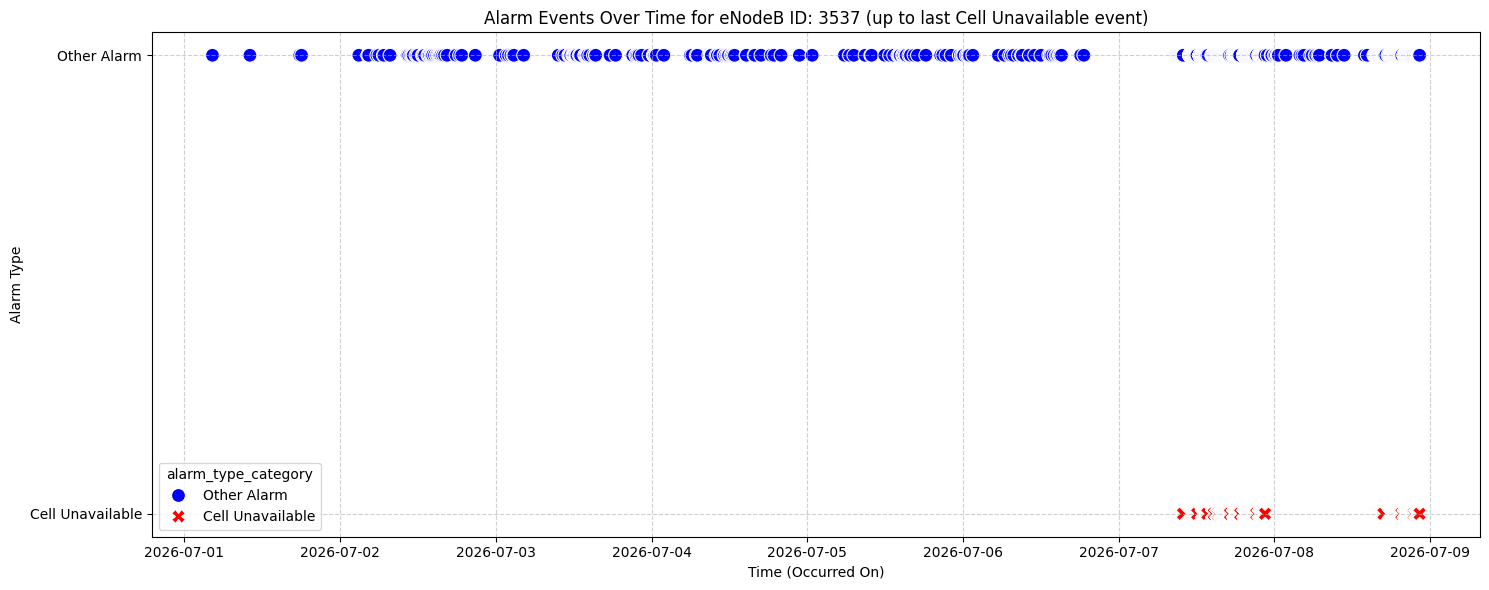

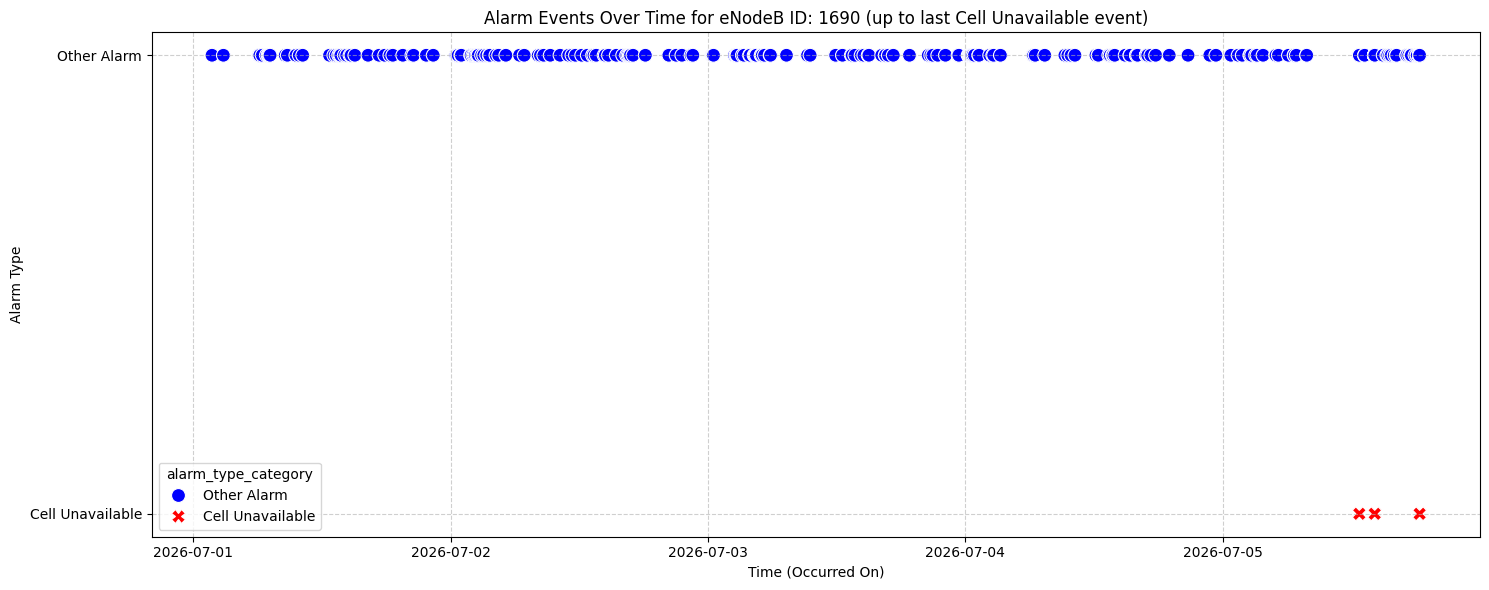

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'enodeb_id' is treated as string for consistent comparison
df_final['enodeb_id'] = df_final['enodeb_id'].astype(str)

# Iterate through each of the top 15 towers and create a time-series plot
for tower_id in top_15_towers['enodeb_id']:
    # Get all alarms for the current tower
    tower_df_full = df_final[df_final['enodeb_id'] == tower_id].sort_values(by='Occurred On (NT)').copy()

    # Identify the last 'Cell Unavailable' event for this specific tower
    cell_unavailable_alarms = tower_df_full[
        tower_df_full['name'].str.contains('cell unavailable', case=False, na=False)
    ]

    if not cell_unavailable_alarms.empty:
        last_cell_unavailable_time = cell_unavailable_alarms['Occurred On (NT)'].max()
        # Filter out all alarms (both 'cell unavailable' and 'other') that occurred AFTER the last 'cell unavailable' event
        tower_df = tower_df_full[tower_df_full['Occurred On (NT)'] <= last_cell_unavailable_time].copy()
    else:
        # This case should ideally not happen if 'top_15_towers' only includes towers with 'cell unavailable' events.
        # If it does, we'll just skip plotting for this tower or plot all its alarms up to its max alarm time.
        # For now, following the request, if no 'cell unavailable' is found (which shouldn't be the case here),
        # we effectively filter out everything after the point if the last 'Cell Unavailable' cannot be determined.
        # Given the context, we should assume `last_cell_unavailable_time` will exist.
        print(f"Warning: No 'Cell Unavailable' alarms found for eNodeB ID: {tower_id} after initial filtering. Skipping.")
        continue # Skip this tower if no 'Cell Unavailable' is found (though it should be present)

    # Classify alarms for plotting
    tower_df['alarm_type_category'] = tower_df['name'].apply(
        lambda x: 'Cell Unavailable' if 'cell unavailable' in str(x).lower() else 'Other Alarm'
    )

    plt.figure(figsize=(15, 6))
    sns.scatterplot(
        x='Occurred On (NT)',
        y='alarm_type_category',
        data=tower_df,
        hue='alarm_type_category',
        style='alarm_type_category',
        markers={'Cell Unavailable': 'X', 'Other Alarm': 'o'},
        s=100, # Marker size
        palette={'Cell Unavailable': 'red', 'Other Alarm': 'blue'},
        legend='full'
    )

    plt.title(f'Alarm Events Over Time for eNodeB ID: {tower_id} (up to last Cell Unavailable event)')
    plt.xlabel('Time (Occurred On)')
    plt.ylabel('Alarm Type')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Additional EDA Analysis: Time-to-Event / Lead-Time Analysis

This analysis aims to understand the temporal relationship between 'other alarms' and 'cell unavailable' events. We will calculate the time difference between alarms preceding a 'cell unavailable' event for each eNodeB and identify the most frequent precursor alarm types within a 1-hour window before a cell failure.


--- Precursor Alarm Analysis ---


,enodeb_id,precursor_alarm_name,unavailable_time,precursor_time,lead_time_seconds
0,82116,RF Unit DC Input Power Failure,2026-07-02 17:04:25,2026-07-02 16:34:33,1792.0
1,82116,RF Unit DC Input Power Failure,2026-07-02 17:04:25,2026-07-02 16:36:18,1687.0
2,82116,Power Module Abnormal,2026-07-02 17:04:25,2026-07-02 16:51:34,771.0
3,82116,Power Module Abnormal,2026-07-02 17:04:25,2026-07-02 16:56:25,480.0
4,82116,RF Unit DC Input Power Failure,2026-07-02 17:04:25,2026-07-02 16:55:03,562.0



Top 10 Most Frequent Precursor Alarms (within 1 hour before Cell Unavailable):


,count
precursor_alarm_name,
SCTP Link Fault,131303
RF Unit Maintenance Link Failure,101997
IP PM Activation Failure,53202
RF Unit DC Input Power Failure,36279
RF Unit External Power Supply Insufficient,25848
GSM Local Cell Unusable,16430
Power Module Abnormal,13035
IP Clock Link Failure,11100
Power Supply DC Output Out of Range,10317


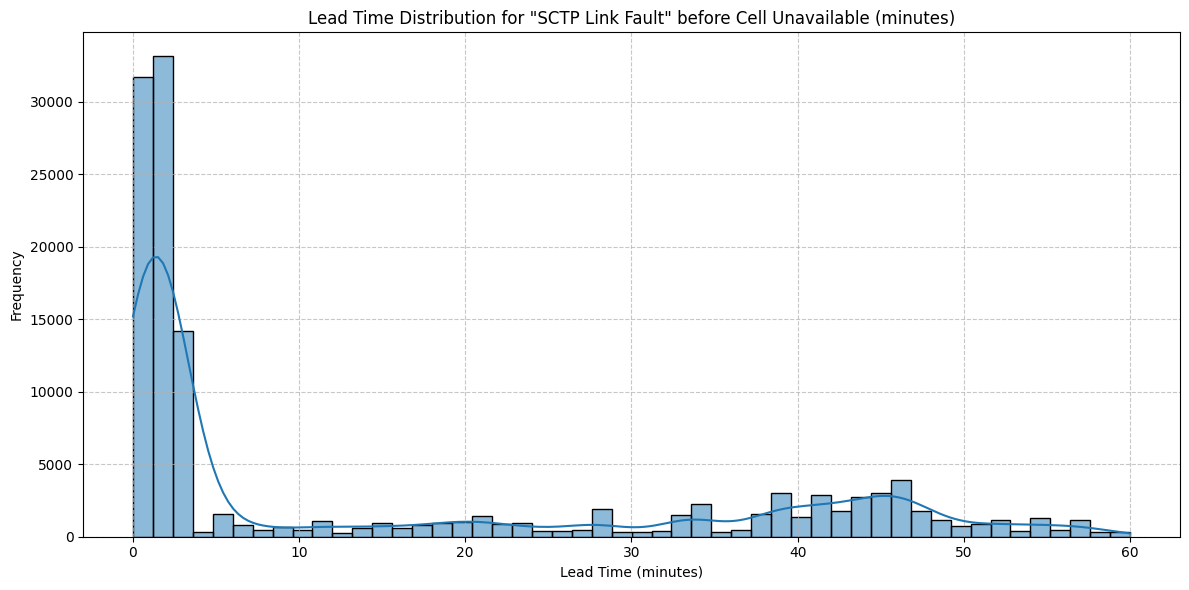

In [46]:
from datetime import timedelta

# Filter for 'Cell Unavailable' alarms
cell_unavailable_events = df_final[df_final['name'].str.contains('cell unavailable', case=False, na=False)].copy()

# Filter for 'Other Alarms'
other_alarms_events = df_final[~df_final['name'].str.contains('cell unavailable', case=False, na=False)].copy()

precursor_alarms = []

# Iterate through each eNodeB that experienced cell unavailability
for enodeb in cell_unavailable_events['enodeb_id'].unique():
    # Get cell unavailable events for the current eNodeB
    enodeb_cell_unavailable = cell_unavailable_events[cell_unavailable_events['enodeb_id'] == enodeb]

    # Get other alarms for the current eNodeB
    enodeb_other_alarms = other_alarms_events[other_alarms_events['enodeb_id'] == enodeb]

    # For each 'cell unavailable' event, find preceding 'other alarms'
    for idx, unavailable_event in enodeb_cell_unavailable.iterrows():
        unavailable_time = unavailable_event['Occurred On (NT)']

        # Find 'other alarms' that occurred within 1 hour before this 'cell unavailable' event
        preceding_alarms = enodeb_other_alarms[
            (enodeb_other_alarms['Occurred On (NT)'] < unavailable_time) &
            (enodeb_other_alarms['Occurred On (NT)'] >= (unavailable_time - timedelta(hours=1)))
        ].copy()

        if not preceding_alarms.empty:
            for p_idx, precursor_event in preceding_alarms.iterrows():
                precursor_alarms.append({
                    'enodeb_id': enodeb,
                    'precursor_alarm_name': precursor_event['name'],
                    'unavailable_time': unavailable_time,
                    'precursor_time': precursor_event['Occurred On (NT)'],
                    'lead_time_seconds': (unavailable_time - precursor_event['Occurred On (NT)']).total_seconds()
                })

if precursor_alarms:
    precursor_df = pd.DataFrame(precursor_alarms)
    print("\n--- Precursor Alarm Analysis ---")
    display(precursor_df.head())

    # Identify the top 10 most frequent precursor alarms
    top_10_precursors = precursor_df['precursor_alarm_name'].value_counts().head(10)
    print("\nTop 10 Most Frequent Precursor Alarms (within 1 hour before Cell Unavailable):")
    display(top_10_precursors)

    # Visualize lead time distribution for the top precursor
    if not top_10_precursors.empty:
        most_frequent_precursor = top_10_precursors.index[0]
        plt.figure(figsize=(12, 6))
        sns.histplot(precursor_df[precursor_df['precursor_alarm_name'] == most_frequent_precursor]['lead_time_seconds'] / 60, bins=50, kde=True)
        plt.title(f'Lead Time Distribution for "{most_frequent_precursor}" before Cell Unavailable (minutes)')
        plt.xlabel('Lead Time (minutes)')
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print("No precursor alarms found within the specified window.")

### Additional EDA Analysis: Temporal Pattern Analysis

This analysis visualizes the frequency of 'cell unavailable' alarms broken down by the hour of the day and the day of the week. This helps in identifying specific time patterns or shifts during which cell unavailability is more prone to occur.

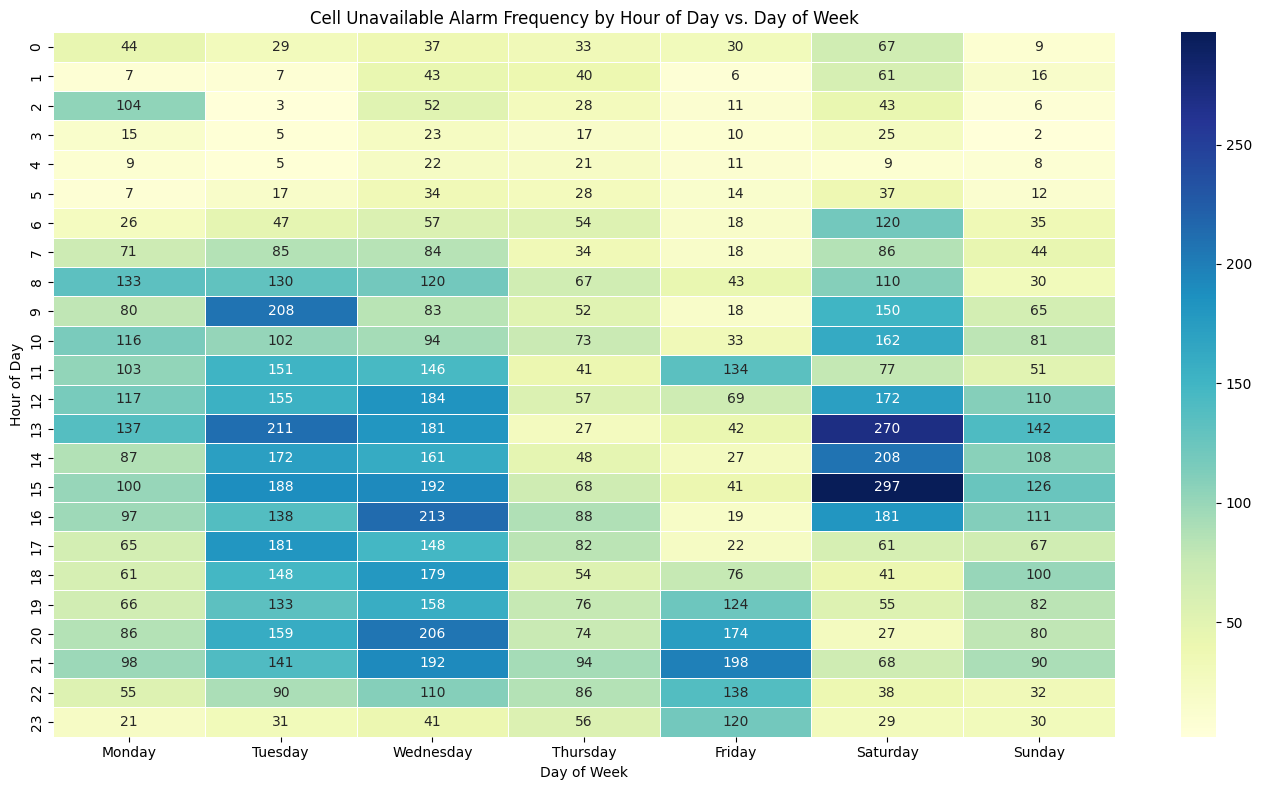

In [47]:
# Extract hour of day and day of week
df_final['hour_of_day'] = df_final['Occurred On (NT)'].dt.hour
df_final['day_of_week'] = df_final['Occurred On (NT)'].dt.day_name()

# Filter for 'Cell Unavailable' alarms
cell_unavailable_for_heatmap = df_final[df_final['name'].str.contains('cell unavailable', case=False, na=False)].copy()

if not cell_unavailable_for_heatmap.empty:
    # Create a pivot table for heatmap
    # Define the order of days of the week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_data = cell_unavailable_for_heatmap.pivot_table(
        index='hour_of_day',
        columns='day_of_week',
        aggfunc='size',
        fill_value=0
    )
    # Reindex columns to ensure correct day order
    heatmap_data = heatmap_data.reindex(columns=day_order, fill_value=0)

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
    plt.title('Cell Unavailable Alarm Frequency by Hour of Day vs. Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Hour of Day')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Cell Unavailable' alarms found to generate heatmap.")

### Additional EDA Analysis: Alarm Co-Occurrence & Co-Correlation

This analysis identifies alarm types that frequently occur together on the same eNodeB within a rolling 30-minute window. A co-occurrence matrix will be generated to show how often different alarm types are present simultaneously or in close proximity, which can indicate underlying causal relationships or common failure modes.


--- Top 15 Alarm Types for Co-occurrence Analysis ---


,0
0,SCTP Link Fault
1,User Plane Path Fault
2,IP PM Activation Failure
3,RF Out of Service
4,RF Unit Maintenance Link Failure
5,X2 Interface Fault
6,RF Unit DC Input Power Failure
7,Mains Input Out of Range
8,GSM Local Cell Unusable
9,BBU CPRI Interface Error


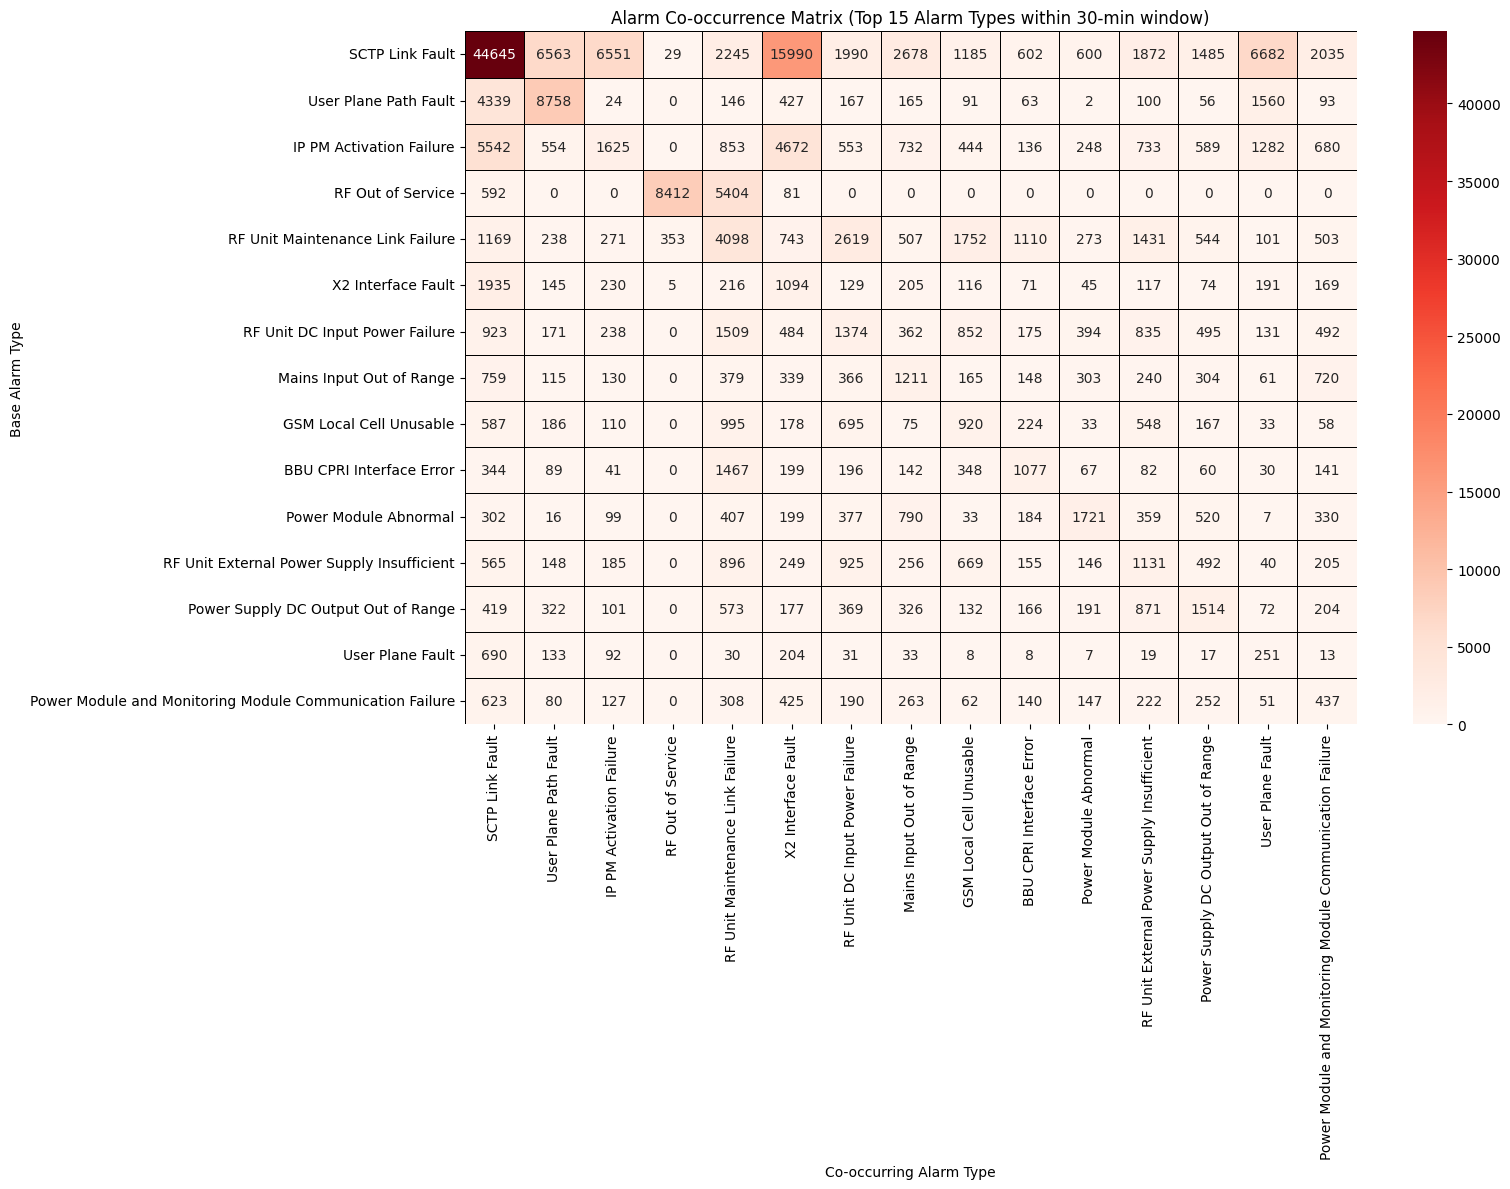

In [48]:
from itertools import combinations

# Identify the top 15 most frequent alarm types (excluding 'cell unavailable')
# Ensure 'name' is string type
df_final['name'] = df_final['name'].astype(str)

# First, get all alarm names excluding 'cell unavailable' specifically
all_alarm_names = df_final[~df_final['name'].str.contains('cell unavailable', case=False, na=False)]['name'].value_counts()

if all_alarm_names.empty:
    print("No 'other alarm' types found for co-occurrence analysis.")
else:
    top_15_alarm_types = all_alarm_names.head(15).index.tolist()

    if not top_15_alarm_types:
        print("Not enough 'other alarm' types to form a top 15 for co-occurrence analysis.")
    else:
        print("\n--- Top 15 Alarm Types for Co-occurrence Analysis ---")
        display(pd.Series(top_15_alarm_types))

        co_occurrence_matrix = pd.DataFrame(0, index=top_15_alarm_types, columns=top_15_alarm_types)

        # Group by eNodeB and iterate through each tower's alarms
        for enodeb, group in df_final.groupby('enodeb_id'):
            # Sort alarms by time
            group = group.sort_values(by='Occurred On (NT)').reset_index(drop=True)

            # Iterate through alarms to find co-occurring alarms within a 30-minute window
            for i in range(len(group)):
                current_alarm_time = group.loc[i, 'Occurred On (NT)']
                current_alarm_name = group.loc[i, 'name']

                # Consider only the top 15 alarm types for the matrix
                if current_alarm_name not in top_15_alarm_types:
                    continue

                # Find alarms in the 30-minute window after the current alarm
                window_alarms = group[
                    (group['Occurred On (NT)'] > current_alarm_time) &
                    (group['Occurred On (NT)'] <= (current_alarm_time + timedelta(minutes=30))) &
                    (group['name'].isin(top_15_alarm_types)) # Only consider top 15 for co-occurrence
                ]['name'].unique()

                # Update co-occurrence matrix
                for co_occurring_alarm in window_alarms:
                    co_occurrence_matrix.loc[current_alarm_name, co_occurring_alarm] += 1
                    # co_occurrence_matrix.loc[co_occurring_alarm, current_alarm_name] += 1 # For symmetric matrix

        plt.figure(figsize=(16, 12))
        sns.heatmap(co_occurrence_matrix, annot=True, fmt='d', cmap='Reds', linewidths=.5, linecolor='black')
        plt.title('Alarm Co-occurrence Matrix (Top 15 Alarm Types within 30-min window)')
        plt.xlabel('Co-occurring Alarm Type')
        plt.ylabel('Base Alarm Type')
        plt.tight_layout()
        plt.show()


### Additional EDA Analysis: Alarm Burst / Volume Tracking

This analysis focuses on identifying periods of unusually high alarm activity (alarm bursts) on eNodeB towers. We will calculate rolling 1-hour alarm counts per eNodeB and plot these volumes against the occurrences of 'cell unavailable' events to see if alarm spikes precede or coincide with cell failures.

/tmp/ipykernel_1388/119988540.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = enodeb_df_original.set_index('Occurred On (NT)').resample('1T').size().to_frame(name='alarm_count')
/tmp/ipykernel_1388/119988540.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  minute_counts['rolling_alarm_count'] = minute_counts['alarm_count'].rolling('1H').sum().fillna(0)


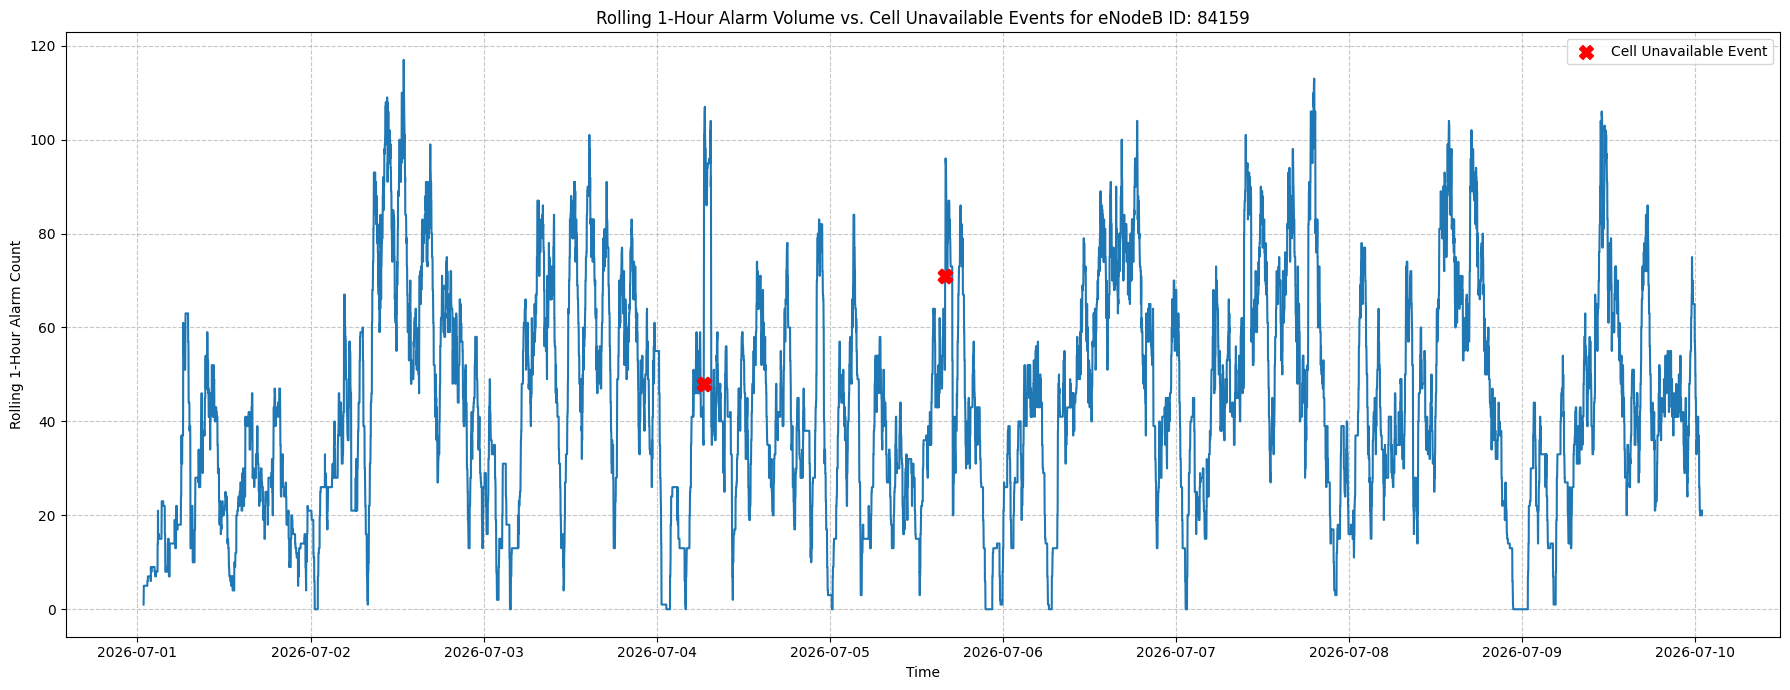

/tmp/ipykernel_1388/119988540.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = enodeb_df_original.set_index('Occurred On (NT)').resample('1T').size().to_frame(name='alarm_count')
/tmp/ipykernel_1388/119988540.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  minute_counts['rolling_alarm_count'] = minute_counts['alarm_count'].rolling('1H').sum().fillna(0)


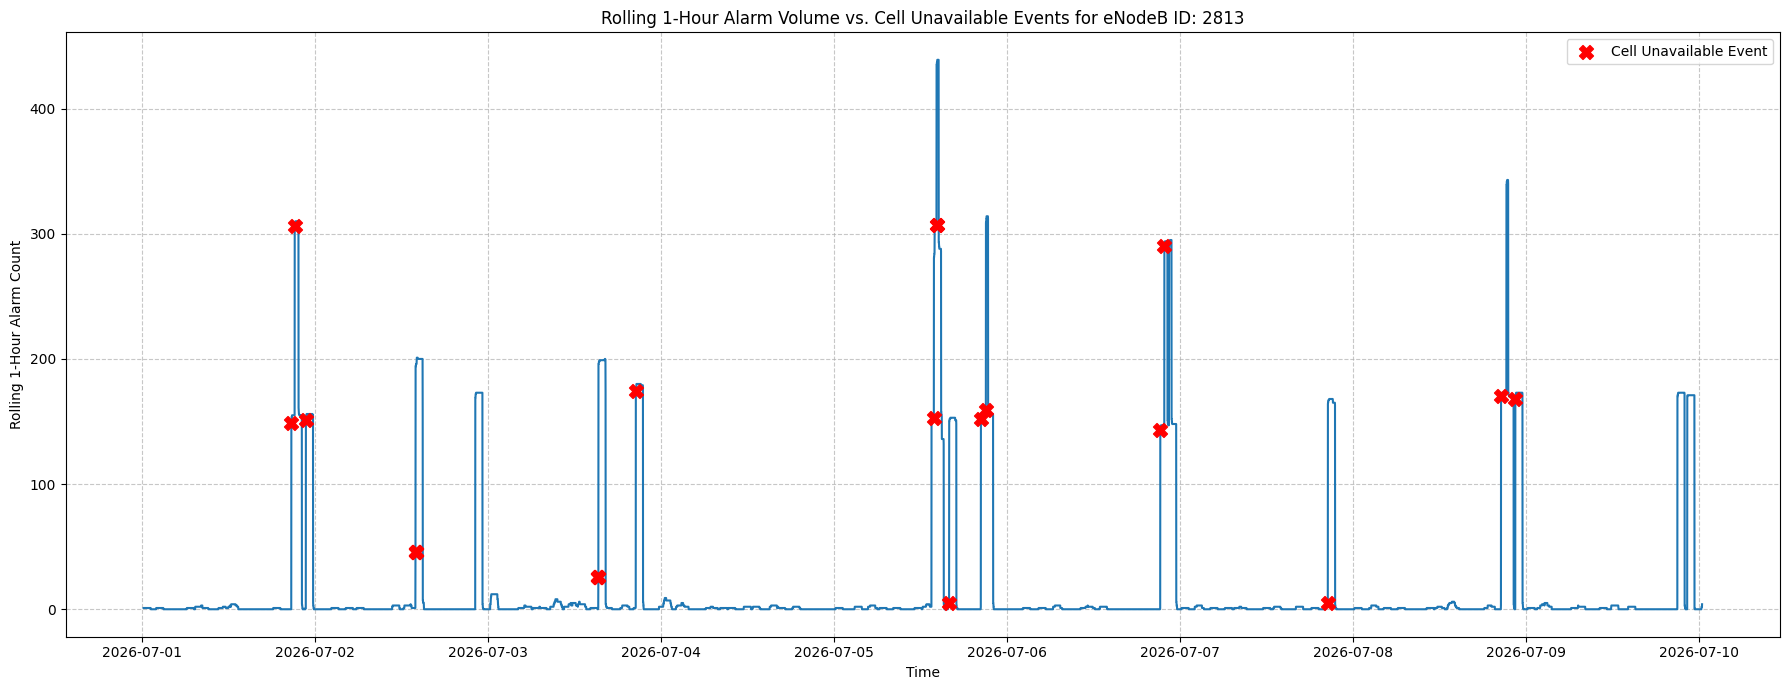

/tmp/ipykernel_1388/119988540.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = enodeb_df_original.set_index('Occurred On (NT)').resample('1T').size().to_frame(name='alarm_count')
/tmp/ipykernel_1388/119988540.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  minute_counts['rolling_alarm_count'] = minute_counts['alarm_count'].rolling('1H').sum().fillna(0)


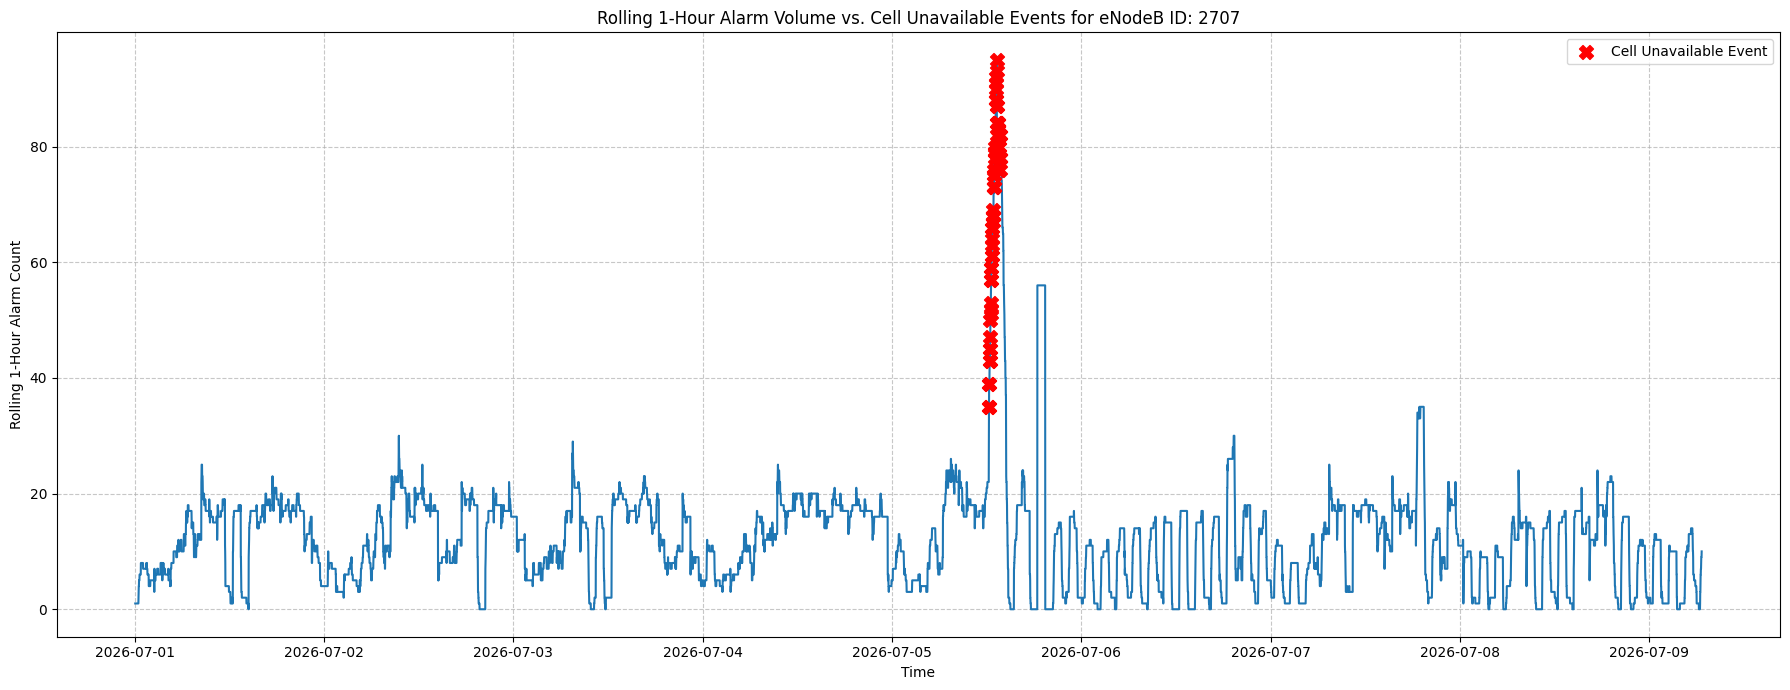

/tmp/ipykernel_1388/119988540.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = enodeb_df_original.set_index('Occurred On (NT)').resample('1T').size().to_frame(name='alarm_count')
/tmp/ipykernel_1388/119988540.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  minute_counts['rolling_alarm_count'] = minute_counts['alarm_count'].rolling('1H').sum().fillna(0)


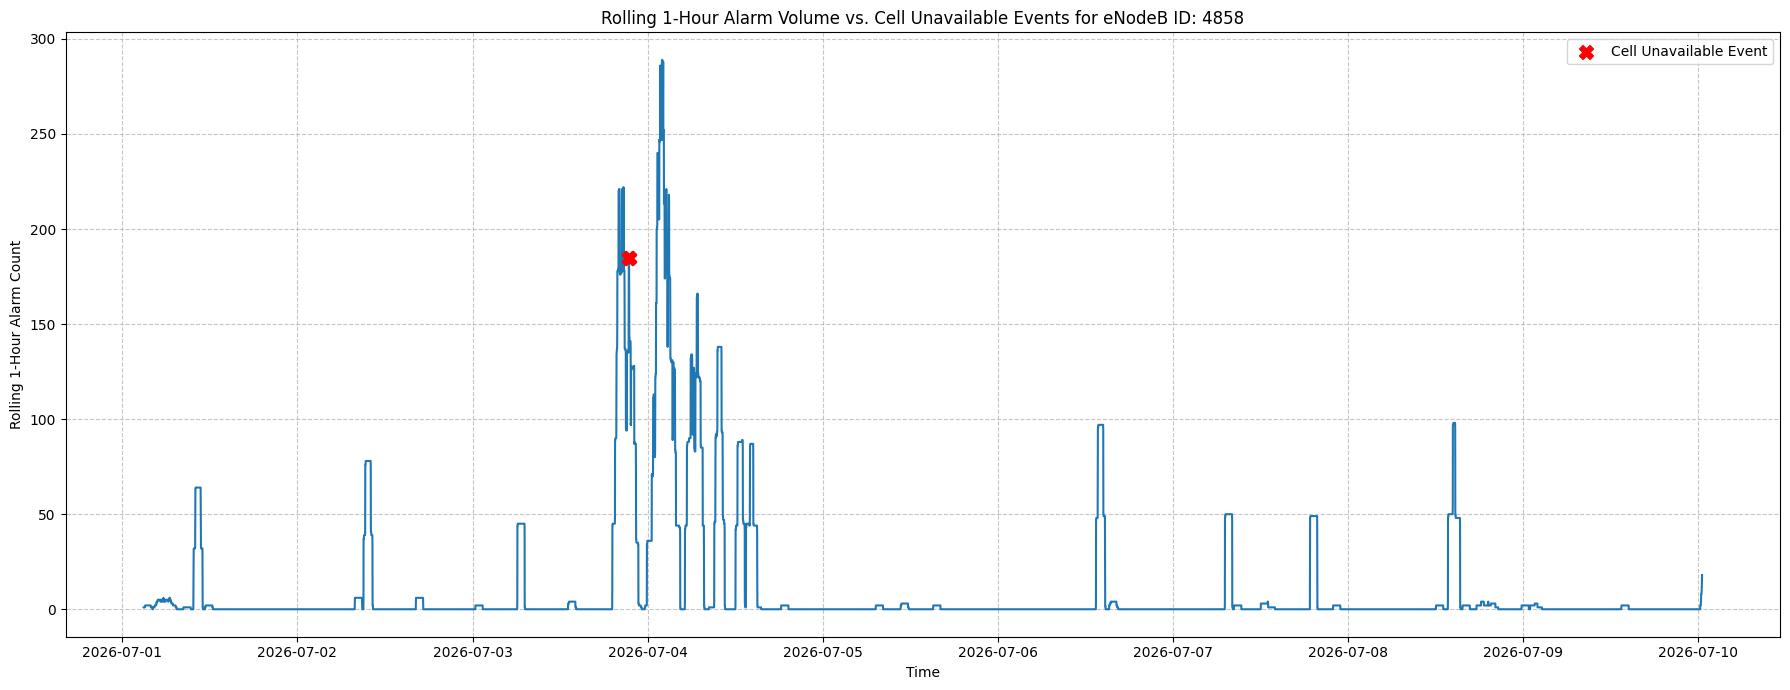

/tmp/ipykernel_1388/119988540.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = enodeb_df_original.set_index('Occurred On (NT)').resample('1T').size().to_frame(name='alarm_count')
/tmp/ipykernel_1388/119988540.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  minute_counts['rolling_alarm_count'] = minute_counts['alarm_count'].rolling('1H').sum().fillna(0)


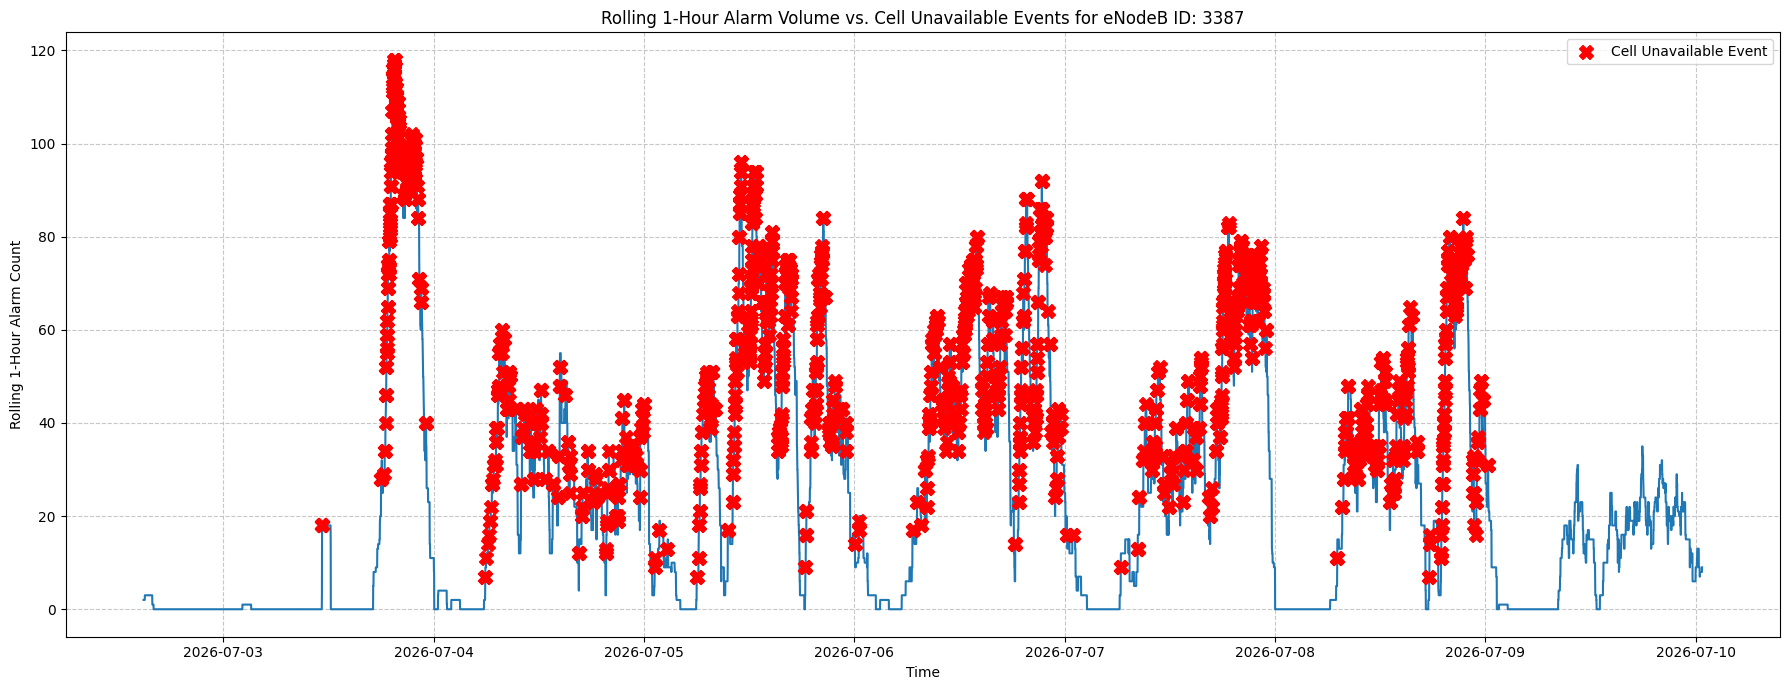

In [50]:
# To avoid SettingWithCopyWarning with chained assignments
pd.options.mode.chained_assignment = None

# Get unique eNodeB IDs for iteration
unique_enodebs = df_final['enodeb_id'].unique()

# Limit to a reasonable number of plots, e.g., top 5 towers by alarm volume for this visualization
# Using top_15_towers defined earlier, we can pick a few for plotting demonstration
enodebs_to_plot = top_15_towers['enodeb_id'].head(5).tolist()

if not enodebs_to_plot:
    print("No eNodeB towers to plot for Alarm Burst / Volume Tracking.")
else:
    for enodeb_id in enodebs_to_plot:
        # Filter data for the current eNodeB
        enodeb_df_original = df_final[df_final['enodeb_id'] == enodeb_id].sort_values(by='Occurred On (NT)').copy()

        if enodeb_df_original.empty:
            continue

        # Create a minute-resampled DataFrame for rolling counts
        # This DataFrame will have a minute-level index (e.g., 2026-07-01 01:45:00)
        minute_counts = enodeb_df_original.set_index('Occurred On (NT)').resample('1T').size().to_frame(name='alarm_count')
        minute_counts['rolling_alarm_count'] = minute_counts['alarm_count'].rolling('1H').sum().fillna(0)

        # Reset index to make 'Occurred On (NT)' a column again for plotting the line
        # This new dataframe, 'rolling_df', is suitable for the line plot
        rolling_df = minute_counts.reset_index()

        # Filter for 'Cell Unavailable' events for this eNodeB from the original df_final
        cell_unavailable_events = enodeb_df_original[enodeb_df_original['name'].str.contains('cell unavailable', case=False, na=False)].copy()

        # To get the rolling_alarm_count at the exact minute of each cell_unavailable_event
        # We need to round down the 'Occurred On (NT)' of cell_unavailable_events to the nearest minute
        # to match the 'Occurred On (NT)' in rolling_df.
        cell_unavailable_events['minute_floor_time'] = cell_unavailable_events['Occurred On (NT)'].dt.floor('min')

        # Merge to get the rolling_alarm_count at the time of each cell unavailable event
        cell_unavailable_events_with_roll = pd.merge(
            cell_unavailable_events,
            rolling_df[['Occurred On (NT)', 'rolling_alarm_count']],
            left_on='minute_floor_time', # Match the minute-floored time
            right_on='Occurred On (NT)',
            how='left',
            suffixes=('_event', '_rolling') # To distinguish original event time from rolling count time
        )

        plt.figure(figsize=(18, 7))

        # Plot rolling alarm count line
        sns.lineplot(x='Occurred On (NT)', y='rolling_alarm_count', data=rolling_df)

        # Mark 'Cell Unavailable' events
        if not cell_unavailable_events_with_roll.empty:
            plt.scatter(
                cell_unavailable_events_with_roll['Occurred On (NT)_event'], # Original event time
                cell_unavailable_events_with_roll['rolling_alarm_count'], # Corresponding rolling count
                color='red',
                marker='X',
                s=100,
                label='Cell Unavailable Event',
                zorder=5 # Ensure markers are on top
            )

        plt.title(f'Rolling 1-Hour Alarm Volume vs. Cell Unavailable Events for eNodeB ID: {enodeb_id}')
        plt.xlabel('Time')
        plt.ylabel('Rolling 1-Hour Alarm Count')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Reset option to default after use if desired
pd.options.mode.chained_assignment = 'warn'

### Step 4: Top 15 Analysis (Alarms Leading to Failure)

This step aims to identify and visualize the Top 15 eNodeB towers that exhibited the highest volume of *other* alarms (i.e., alarms that are not 'cell unavailable') within the context of ultimately experiencing 'cell unavailable' events. This helps to highlight towers with significant pre-failure activity.


Top 15 eNodeB Towers with Highest Volume of Other Alarms (pre/alongside 'cell unavailable'):


,enodeb_id,other_alarm_count
342,84159,9401
157,2813,3736
141,2707,2381
268,4858,2207
210,3387,2111
145,2727,2104
205,3333,2040
197,3235,1860
98,2095,1803
165,2907,1667


/tmp/ipykernel_1388/1036315795.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='other_alarm_count', y='enodeb_id', data=top_15_towers, palette='viridis')


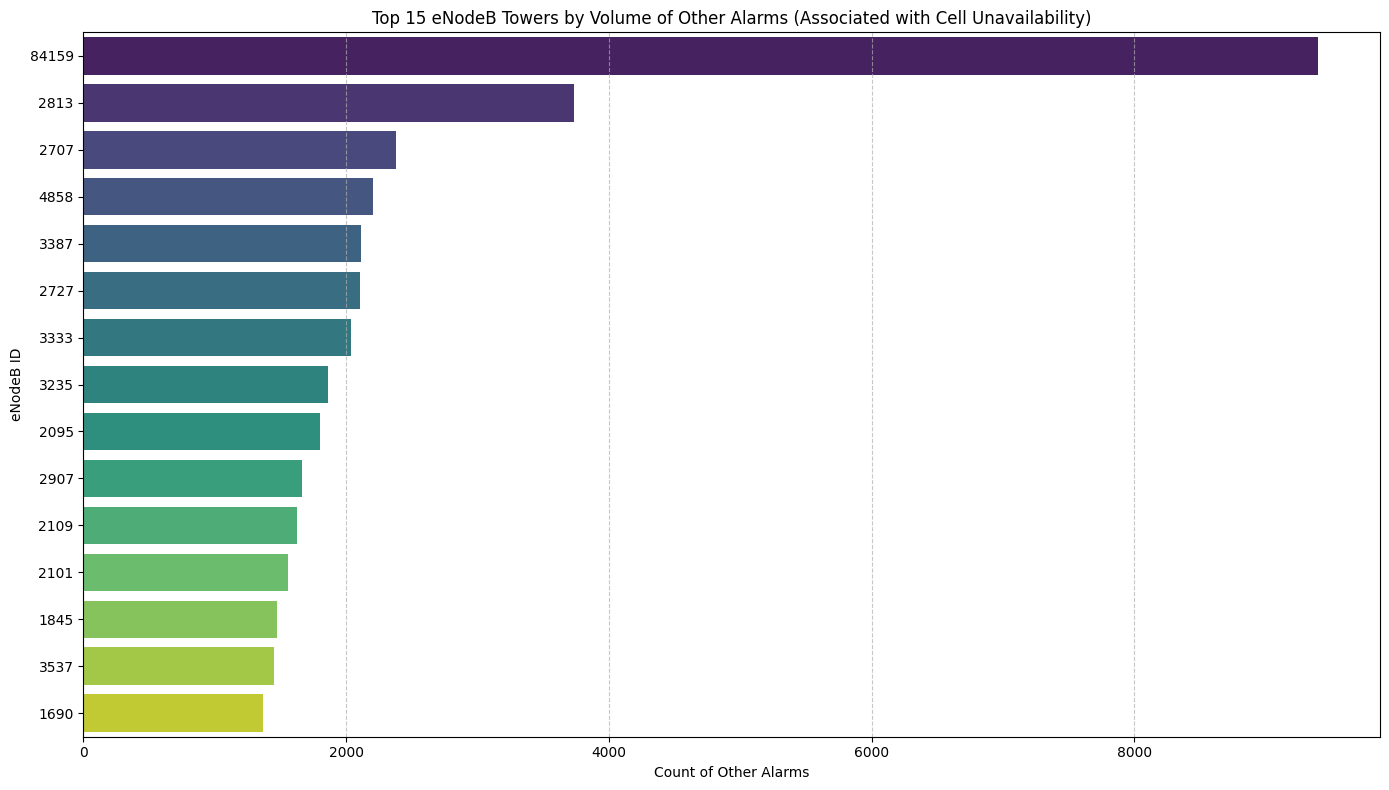

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'enodeb_id' is treated as string for robust comparison
df_final['enodeb_id'] = df_final['enodeb_id'].astype(str)

# Filter out rows where enodeb_id is '-' (explicitly applying this filter again)
df_final_filtered = df_final[df_final['enodeb_id'].str.strip() != '-'].copy()

# The 'enodeb_id' and 'name' columns are now guaranteed to exist from previous steps.
# Filter for non-'cell unavailable' alarms for the towers identified in Step 3
# (df_final_filtered already contains only towers with 'cell unavailable' events, and now no '-')
other_alarms_df = df_final_filtered[
    ~df_final_filtered['name'].str.contains('cell unavailable', case=False, na=False)
].copy()

# Count the volume of 'other' alarms per eNodeB tower
alarm_volume_per_tower = other_alarms_df.groupby('enodeb_id').size().reset_index(name='other_alarm_count')

# Get the Top 15 eNodeB towers with the highest volume of 'other' alarms
top_15_towers = alarm_volume_per_tower.sort_values(by='other_alarm_count', ascending=False).head(15)

print("\nTop 15 eNodeB Towers with Highest Volume of Other Alarms (pre/alongside 'cell unavailable'):")
display(top_15_towers)

# Create a Seaborn bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='other_alarm_count', y='enodeb_id', data=top_15_towers, palette='viridis')
plt.title('Top 15 eNodeB Towers by Volume of Other Alarms (Associated with Cell Unavailability)')
plt.xlabel('Count of Other Alarms')
plt.ylabel('eNodeB ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 5: Data Validation & EDA Summary

This final step provides a summary of the processed data, including descriptive statistics for numerical columns, counts of missing values across all columns, and a frequency table of the most common alarm types in the `name` column. This helps in understanding the data's overall quality and content after the filtering steps.

In [39]:
# 1. Output summary statistics
print("\n--- Summary Statistics of the Final DataFrame ---")
display(df_final.describe(include='all')) # include='all' to get stats for non-numeric columns too

# 2. Missing value counts
print("\n--- Missing Value Counts ---")
missing_values = df_final.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
if not missing_values.empty:
    display(missing_values)
else:
    print("No missing values found in the DataFrame.")

# 3. Frequency table of the most common alarm types in the 'name' column
# The 'name' column is now guaranteed to exist.
print("\n--- Top 20 Most Common Alarm Types ---")
display(df_final['name'].value_counts().head(20))


--- Summary Statistics of the Final DataFrame ---


,,Severity,Occurred On (NT),Cleared On (NT),Alarm ID,MO Name,Comment,name,Location Information,Additional Information,...,RRU Name,Received On (ST),Request ID,Subnet,Toggling Times,Trouble Ticket ID,Type,User Label,enodeb_id,gNodeB ID
count,160557,160557,160557,160557,160557.000000,160557,160557,160557,160557,160557,...,156387,160557,160557,160557,160557.000000,160557,160557,160557,160557,160557
unique,9,4,77391,71654,NaN,4997,29,148,32298,8114,...,287,75763,1,21,NaN,1,11,1,399,8
top,Root alarm,Major,2026-07-05 18:21:35,2026-07-09 18:17:56,NaN,Object ID=0,-,SCTP Link Fault,Service Type=X2,"RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",...,-,2026-07-07 06:07:40,-,ROOT/RAN Subnet/BTS/BTS3900 - Co-MPT/GL,NaN,-,Trunk system,-,84159,-
freq,130453,121621,214,221,NaN,7139,160497,65519,1585,3135,...,136476,386,160557,44691,NaN,160557,91314,160557,9413,157276
mean,NaN,NaN,NaN,NaN,27206.620172,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.046582,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,4887.775440,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.843855,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,25600.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,25888.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,25900.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,26564.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN



--- Missing Value Counts ---


,0
Common Alarm Identifier,159562
RRU Name,4170



--- Top 20 Most Common Alarm Types ---


,count
name,
SCTP Link Fault,65519
Cell Unavailable,13484
User Plane Path Fault,11828
IP PM Activation Failure,10001
RF Out of Service,8549
RF Unit Maintenance Link Failure,6385
X2 Interface Fault,5693
RF Unit DC Input Power Failure,3601
Mains Input Out of Range,2839


### Save Processed Data to Google Drive (Parquet Format)

This step saves the `df_final` DataFrame, which contains the cleaned and filtered telecom alarm data, to your Google Drive in Parquet format. Parquet is an efficient columnar storage format that is ideal for large datasets and is optimized for use with Pandas, making future loading faster and more memory-efficient.

In [52]:
# Define the output path in your Google Drive
# IMPORTANT: Update this path to your desired save location
output_parquet_path = '/content/drive/MyDrive/MobitelData/processed_telecom_data.parquet'

# Ensure the directory exists before saving
output_dir = os.path.dirname(output_parquet_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the DataFrame to Parquet
df_final.to_parquet(output_parquet_path, index=False)

print(f"DataFrame successfully saved to: {output_parquet_path}")

DataFrame successfully saved to: /content/drive/MyDrive/MobitelData/processed_telecom_data.parquet


### Save Processed Data to Google Drive (CSV Format)

This step saves the `df_final` DataFrame, which contains the cleaned and filtered telecom alarm data, to your Google Drive in CSV format. This can be useful for sharing with tools that prefer CSV or for external analysis.

In [53]:
# Define the output path in your Google Drive for the CSV file
# IMPORTANT: Update this path to your desired save location
output_csv_path = '/content/drive/MyDrive/MobitelData/processed_telecom_data.csv'

# Ensure the directory exists before saving
output_dir = os.path.dirname(output_csv_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the DataFrame to CSV
df_final.to_csv(output_csv_path, index=False)

print(f"DataFrame successfully saved to: {output_csv_path}")

DataFrame successfully saved to: /content/drive/MyDrive/MobitelData/processed_telecom_data.csv


## Feature Engineering: Cell ID Extraction

This step involves extracting a specific `cell_id` from the `Location Information` and `Additional Information` columns. This is crucial for distinguishing alarms that affect a particular cell from those that impact the entire eNodeB tower.

We will use regular expressions to find patterns like `Cell ID=X` or `Local Cell ID=X`. If a `cell_id` cannot be extracted, it indicates a tower-level alarm, and we will assign a placeholder value of `'Tower-Level'` to the `cell_id` column for such cases.

In [55]:
import re

# Initialize 'cell_id' column with a placeholder for not found values
df_final['cell_id'] = pd.NA

# Function to extract Cell ID using regex from a given text
def extract_cell_id(text):
    if pd.isna(text):
        return pd.NA
    text = str(text)
    # Only try to find 'Cell ID=...'
    match = re.search(r'Cell ID=(\d+)', text)
    if match:
        return int(match.group(1))
    return pd.NA

# Apply extraction to 'Location Information' column
df_final['cell_id'] = df_final['Location Information'].apply(extract_cell_id)

# For any remaining missing 'cell_id', try 'Additional Information' column
# We use .loc to modify the original DataFrame section directly, avoiding SettingWithCopyWarning
missing_cell_id_indices = df_final['cell_id'].isna()
df_final.loc[missing_cell_id_indices, 'cell_id'] = \
    df_final.loc[missing_cell_id_indices, 'Additional Information'].apply(extract_cell_id)

# Fill any still missing 'cell_id' values with 'Tower-Level'
# Reassign the column to avoid `inplace=True` FutureWarning
df_final['cell_id'] = df_final['cell_id'].fillna('Tower-Level')

print("Feature Engineering: 'cell_id' extracted and missing values handled.")
print("First 5 rows with new 'cell_id' column:")
display(df_final[['Location Information', 'Additional Information', 'name', 'enodeb_id', 'cell_id']].head())
print("Value counts for new 'cell_id' column (top 10):")
display(df_final['cell_id'].value_counts().head(10))

Feature Engineering: 'cell_id' extracted and missing values handled.
First 5 rows with new 'cell_id' column:


,Location Information,Additional Information,name,enodeb_id,cell_id
0,"Link No.=70053, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",SCTP Link Fault,84362,Tower-Level
1,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",Cell Unavailable,82116,82
2,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",Cell Unavailable,82116,80
7,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",Cell Unavailable,82116,82
8,"eNodeB Function Name=MTAKU2_L_Akuressa2_IP_Ma,...","RAT_INFO=GL, AFFECTED_RAT=L, DID=NULL, Cumulat...",Cell Unavailable,82116,80


Value counts for new 'cell_id' column (top 10):


,count
cell_id,
Tower-Level,134989
2,4625
1,4218
0,2387
3,2038
5,1743
81,1732
4,1715
82,1438
